# The Broker's Paradox
## Testing Burt's Structural Holes Theory on 168,000 Twitch Streamers

**Course:** CSCE 676 — Data Mining (Spring 2026)
**Author:** Shivam Singhal
**Video:** [The Broker's Paradox (2 min)](https://youtu.be/U0zgOHqXI7Q)

---

## Abstract

For thirty years, Ronald Burt's *structural holes* theory has held that individuals who bridge disconnected groups in organizational networks enjoy a measurable success premium — faster promotions, higher pay, better ideas. Does this theory generalize to the creator economy? We test it on a snapshot of 168,114 Twitch streamers linked by 6.8M mutual-follow ties, with Twitch Affiliate status as the success outcome.

We operationalize "bridge" three ways — ego-network brokerage (Burt's classical constraint), cross-community bridging (via Louvain), and cross-language bridging — and find the three measures are nearly uncorrelated at the aggregate level (Spearman 0.07–0.26). Controlling for degree, account age, and language-majority status, we find:

- **Ego-network brokerage pays** (OR = **1.320** [1.293, 1.348] per SD, p < 0.001)
- **Structural community bridging is flat at aggregate** (OR = **1.014** [1.001, 1.028]) but masks strong opposite subgroup effects
- **Cross-language bridging is penalized** (OR = **0.933** [0.919, 0.946], p < 0.001)

A likelihood-ratio test confirms the bridge measures add joint explanatory power beyond controls (χ² = 920.92 on 3 df, p ≈ 0), though the predictive gain is modest (5-fold CV AUC 0.698 → 0.701). A formal interaction test confirms a striking English/non-English asymmetry (`pc_language × is_english` OR = **0.733**, p < 0.001): non-English speakers who bridge toward English are *rewarded*, English speakers who bridge outward are *penalized*. An OLS on `log_views` reveals an "affiliate-vs-views inversion": the network positions that help reach Affiliate status *hurt* viewership, and vice versa — the two success metrics reward opposite structures. A node2vec-based fourth bridge measure confirms the main finding is robust to the choice of community-detection method.

**The unifying insight:** Burt's theory implicitly assumes bridges operate within a shared attention pool. Twitch's language communities fragment that pool — and the theory breaks at the fragmentation boundary.

## A note on how this project evolved

Earlier checkpoints (included in `checkpoints/`) explored a broader scope — three candidate datasets in Checkpoint 1, three loosely-connected research questions in Checkpoint 2. Acting on explicit guidance from Prof. Caverlee — *"What we do not want is a hodge-podge project that tries N different things all in a shallow way... we want a strong clear deep approach"* — I pivoted to a single focused research question: **does Burt's structural holes theory apply to the creator economy?**

The checkpoints remain in the repository for transparency and to document the narrowing process. The story told here is the final one: one theoretical frame, one dataset, one outcome family, stress-tested along several robustness dimensions.

## 1. Motivation & Research Question

**Central question:** *On Twitch, do streamers who bridge disconnected communities enjoy a success premium — as Burt's classic social-capital theory predicts — after controlling for reach and tenure? And does the answer depend on what kind of bridge we mean?*

### Why this question matters

Creator-economy platforms like Twitch, YouTube, and TikTok have become primary livelihoods for millions, yet we have limited empirical understanding of what structural positions predict success on them. The dominant practitioner framing emphasizes *audience* metrics — views, followers, engagement. But decades of organizational sociology suggest that **who you know** (network position) matters as much as **how many** (network size).

Ronald Burt's *structural holes* theory, introduced in *Structural Holes: The Social Structure of Competition* (Harvard, 1992) and refined over 30+ years, argues that people positioned as bridges between otherwise-disconnected groups enjoy advantages in information, control, and brokerage. The theory has been validated across managers, scientists, investment bankers, and TQM teams — but, to our knowledge, has never been rigorously tested against network data on a creator platform.

### What makes Twitch a natural laboratory

1. **Peer recognition as an edge type.** Twitch's mutual-follow graph represents streamer-to-streamer acknowledgment, not just audience consumption — this is the appropriate structure for testing peer-based social capital.
2. **Natural community boundaries.** The platform splits into 20+ language communities, giving us a principled, externally-validated partition to test *cross-community* bridging.
3. **An objective, binary success outcome.** The Affiliate program is Twitch's monetization gate (50 followers, 500 broadcast minutes, 7 unique days, 3+ average viewers in 30 days). Roughly half the sample has crossed it — a clean ~50/50 outcome.

### Three operationalizations of "bridge"

Burt's theory refers broadly to "bridging disconnected groups" — but in practice, this can mean several distinct things. We measure three primary operationalizations plus a fourth (node2vec) as a robustness check:

1. **Ego-network brokerage** (Burt 1992): low *network constraint* — your immediate contacts don't know each other.
2. **Structural community bridging** (Guimerà & Amaral 2005): high *participation coefficient* across algorithmically detected communities (Louvain).
3. **Cross-language bridging**: high participation coefficient across language communities — the externally-given partition.
4. **Embedding-based bridging** (robustness): participation coefficient over clusters of node2vec embeddings — checks that our findings don't depend on the specific community-detection algorithm.

These are conceptually related but empirically distinct; a key contribution of this work is quantifying how different they are and showing they have **opposite** relationships to success on Twitch.

## 2. Data & Setup

### Dataset: SNAP Twitch Gamers (Rozemberczki & Sarkar, 2021)

- **168,114 nodes** — Twitch streamers active as of Spring 2018
- **6,797,557 edges** — mutual-follow ties (undirected)
- **Node attributes:** views, language, account age (`created_at`), `updated_at`, `affiliate`, `dead_account`, `mature` (adult content flag), `life_time`
- The graph is a single connected component.

### Compute environment

Google Colab, T4 GPU. Expensive computations (Louvain, Burt's constraint, PageRank, node2vec) are cached to disk; subsequent runs complete in < 30 seconds.

In [2]:
# Dependency install — only run once per Colab session.
# If numpy binary errors appear, restart the runtime (Runtime -> Restart session), then skip this cell.
!pip install -q python-louvain gensim
!pip install -q --upgrade igraph
!pip install -q "numpy<2.0" "pandas>=2.0" pyarrow
print("Dependencies installed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 67.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 77.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 

In [1]:
import warnings; warnings.filterwarnings("ignore")
import os, time, urllib.request, zipfile, subprocess, sys, pickle, json
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats as scistats
from scipy.stats import spearmanr, chi2_contingency, chi2

from sklearn.linear_model import LogisticRegression as SKLogit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (normalized_mutual_info_score, roc_auc_score,
                             average_precision_score)
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import StratifiedKFold
from sklearn.cluster import KMeans

matplotlib.rcParams.update({"figure.dpi": 130, "font.size": 10,
                            "axes.spines.top": False, "axes.spines.right": False})
RS = 42
np.random.seed(RS)

os.makedirs("assets/figures", exist_ok=True)
os.makedirs("cache", exist_ok=True)
print("Setup complete.")

Setup complete.


In [2]:
# Download + unpack SNAP Twitch Gamers
DATADIR = ".data"
os.makedirs(DATADIR, exist_ok=True)
ZIPURL  = "https://snap.stanford.edu/data/twitch_gamers.zip"
ZIPPATH = os.path.join(DATADIR, "twitch_gamers.zip")

if not os.path.exists(ZIPPATH):
    print("Downloading Twitch Gamers dataset...")
    urllib.request.urlretrieve(ZIPURL, ZIPPATH)

with zipfile.ZipFile(ZIPPATH, "r") as z:
    z.extractall(DATADIR)

edges = pd.read_csv(os.path.join(DATADIR, "large_twitch_edges.csv"))
nodes = pd.read_csv(os.path.join(DATADIR, "large_twitch_features.csv"))

print(f"Edges: {edges.shape} | Nodes: {nodes.shape}")
print(f"Affiliate prevalence    : {nodes['affiliate'].mean()*100:.1f}%")
print(f"Dead-account prevalence : {nodes['dead_account'].mean()*100:.2f}%")

Edges: (6797557, 2) | Nodes: (168114, 9)
Affiliate prevalence    : 48.5%
Dead-account prevalence : 3.07%


In [3]:
# Feature engineering
nodes["log_views"] = np.log1p(nodes["views"])

print("Computing degree...")
deg_counter = Counter()
for u, v in edges[["numeric_id_1", "numeric_id_2"]].values:
    deg_counter[u] += 1
    deg_counter[v] += 1
nodes["degree"]     = nodes["numeric_id"].map(deg_counter).fillna(0).astype(int)
nodes["log_degree"] = np.log1p(nodes["degree"])

nodes["created_at"] = pd.to_datetime(nodes["created_at"])
nodes["updated_at"] = pd.to_datetime(nodes["updated_at"])
SNAPSHOT = pd.Timestamp("2018-10-12")
nodes["account_age_days"] = (SNAPSHOT - nodes["created_at"]).dt.days.clip(lower=0)

top5 = nodes["language"].value_counts().head(5).index.tolist()
nodes["is_english"]   = (nodes["language"] == "EN").astype(int)
nodes["is_top5_lang"] = nodes["language"].isin(top5).astype(int)

print(nodes[["degree", "log_views", "life_time", "account_age_days", "affiliate"]]
      .describe().round(2))

Computing degree...
          degree  log_views  life_time  account_age_days  affiliate
count  168114.00  168114.00  168114.00         168114.00  168114.00
mean       80.87       8.53    1541.81           1556.52       0.49
std       314.16       2.01     715.70            716.06       0.50
min         1.00       0.00      11.00            152.00       0.00
25%        13.00       7.26     997.00           1010.00       0.00
50%        32.00       8.32    1540.00           1558.00       0.00
75%        75.00       9.56    2027.00           2045.00       1.00
max     35279.00      19.77    4161.00           4161.00       1.00


In [4]:
# Graph construction (NetworkX for flexibility, igraph for speed)
NX_PKL = "cache/G_nx.pkl"; IG_PKL = "cache/G_ig.pkl"

if os.path.exists(NX_PKL):
    print("Loading cached NetworkX graph...")
    with open(NX_PKL, "rb") as f: G = pickle.load(f)
else:
    print("Building NetworkX graph...")
    t0 = time.time()
    G = nx.from_pandas_edgelist(edges, "numeric_id_1", "numeric_id_2")
    print(f"  Built in {time.time()-t0:.1f}s")
    with open(NX_PKL, "wb") as f: pickle.dump(G, f)

print(f"NetworkX: {G.number_of_nodes():,} nodes | {G.number_of_edges():,} edges | "
      f"connected = {nx.is_connected(G)}")

if os.path.exists(IG_PKL):
    print("Loading cached igraph...")
    with open(IG_PKL, "rb") as f: G_ig = pickle.load(f)
else:
    print("Building igraph...")
    t0 = time.time()
    all_nodes = sorted(set(edges["numeric_id_1"]) | set(edges["numeric_id_2"]))
    id_to_idx = {nid: i for i, nid in enumerate(all_nodes)}
    idx_to_id = {i: nid for nid, i in id_to_idx.items()}
    el = [(id_to_idx[u], id_to_idx[v]) for u, v in edges[["numeric_id_1", "numeric_id_2"]].values]
    G_ig = ig.Graph(n=len(all_nodes), edges=el, directed=False)
    G_ig["id_to_idx"] = id_to_idx; G_ig["idx_to_id"] = idx_to_id
    print(f"  Built in {time.time()-t0:.1f}s")
    with open(IG_PKL, "wb") as f: pickle.dump(G_ig, f)

print(f"igraph:   {G_ig.vcount():,} nodes | {G_ig.ecount():,} edges")

Building NetworkX graph...
  Built in 22.8s
NetworkX: 168,114 nodes | 6,797,557 edges | connected = True
Building igraph...
  Built in 22.7s
igraph:   168,114 nodes | 6,797,557 edges


## 3. Methods

### 3.1 Community detection
We run Louvain community detection (Blondel et al. 2008) on the full graph at resolution 1.0 (modularity-maximizing default), with a fixed seed for reproducibility.

### 3.2 Three bridge measures
- **Ego-network brokerage** (`brokerage = 1 − Burt constraint`). Burt's constraint is *O(k²)* per node, so we cap computation at degree ≤ 500 — this excludes ~1.8% of nodes. Computed via `igraph.Graph.constraint()`.
- **Structural community bridging** (`pc_louvain`). Participation coefficient (Guimerà & Amaral, 2005) with respect to Louvain communities:

$$P_i = 1 - \sum_s \left(\frac{k_{is}}{k_i}\right)^2$$

- **Cross-language bridging** (`pc_language`). Same formula, but the partition is the externally-given language attribute.

### 3.3 Controls
`log_degree` (scale), `account_age_days` (tenure), `is_english` (majority-language dummy), `mature` (adult-content flag). We deliberately drop `life_time` after an initial fit reveals extreme collinearity with `account_age_days`.

### 3.4 Inference
Logistic regression with Wald-test 95% confidence intervals from the observed Fisher information matrix. Additionally we run:
- Propensity-score matching (1:1 caliper at 0.05) as a non-parametric robustness check
- A likelihood-ratio test for joint significance of the bridge measures
- VIF diagnostics for multicollinearity
- 5-fold cross-validation for out-of-sample discrimination
- A formal interaction test for the English/non-English heterogeneity
- A node2vec-based fourth bridge measure as a partition-free sanity check

In [5]:
# Louvain community detection
LOUVAIN_PKL = "cache/louvain_partition.pkl"

def load_louvain():
    try:
        import community as cl
        if not hasattr(cl, "best_partition"): raise AttributeError
        return cl
    except (ImportError, AttributeError):
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--force-reinstall", "python-louvain", "-q"], check=True)
        for m in list(sys.modules):
            if "community" in m: del sys.modules[m]
        import community as cl
        return cl

community_louvain = load_louvain()

if os.path.exists(LOUVAIN_PKL):
    print("Loading cached Louvain partition...")
    with open(LOUVAIN_PKL, "rb") as f: partition = pickle.load(f)
else:
    print("Running Louvain on full graph (~3-5 min)...")
    t0 = time.time()
    partition = community_louvain.best_partition(G, random_state=RS, resolution=1.0)
    print(f"  Done in {time.time()-t0:.1f}s")
    with open(LOUVAIN_PKL, "wb") as f: pickle.dump(partition, f)

n_comm = len(set(partition.values()))
mod_q  = community_louvain.modularity(partition, G)
comm_sz = pd.Series(Counter(partition.values())).sort_values(ascending=False)

print(f"\nLouvain: {n_comm} communities | Modularity Q = {mod_q:.4f}")
print(f"Community sizes — median: {int(comm_sz.median())}, "
      f"max: {comm_sz.max():,}, top-10: {comm_sz.head(10).tolist()}")

nodes["louvain_comm"] = nodes["numeric_id"].map(partition)

lang_map = dict(zip(nodes["numeric_id"], nodes["language"]))
common = [n for n in partition if n in lang_map]
nmi_lang = normalized_mutual_info_score(
    [lang_map[n] for n in common], [partition[n] for n in common])
print(f"\nNMI(Louvain, Language) = {nmi_lang:.4f}")

Running Louvain on full graph (~3-5 min)...
  Done in 484.7s

Louvain: 32 communities | Modularity Q = 0.4180
Community sizes — median: 453, max: 47,419, top-10: [47419, 34678, 24572, 24146, 8779, 6219, 5080, 5016, 4608, 2010]

NMI(Louvain, Language) = 0.5152


In [6]:
# Participation coefficient (both partitions)
def participation_coefficient(G, partition):
    """Guimerà & Amaral (2005): P_i = 1 - sum_s (k_is/k_i)^2"""
    pc = {}
    for node in G.nodes():
        nbrs = list(G.neighbors(node))
        if not nbrs:
            pc[node] = 0.0; continue
        counts = Counter(partition.get(nb) for nb in nbrs if nb in partition)
        total = sum(counts.values())
        if total == 0:
            pc[node] = 0.0; continue
        pc[node] = 1.0 - sum((c/total)**2 for c in counts.values())
    return pc

PC_LOUV = "cache/pc_louvain.pkl"; PC_LANG = "cache/pc_language.pkl"

if os.path.exists(PC_LOUV):
    with open(PC_LOUV, "rb") as f: pc_louv = pickle.load(f)
    with open(PC_LANG, "rb") as f: pc_lang = pickle.load(f)
    print("Loaded cached participation coefficients.")
else:
    print("Computing PC (Louvain)..."); t0 = time.time()
    pc_louv = participation_coefficient(G, partition)
    print(f"  Done in {time.time()-t0:.1f}s")
    print("Computing PC (Language)..."); t0 = time.time()
    pc_lang = participation_coefficient(G, lang_map)
    print(f"  Done in {time.time()-t0:.1f}s")
    with open(PC_LOUV, "wb") as f: pickle.dump(pc_louv, f)
    with open(PC_LANG, "wb") as f: pickle.dump(pc_lang, f)

nodes["pc_louvain"]  = nodes["numeric_id"].map(pc_louv).fillna(0)
nodes["pc_language"] = nodes["numeric_id"].map(pc_lang).fillna(0)

r_pc, _ = spearmanr(nodes["pc_louvain"], nodes["pc_language"])
print(f"\nSpearman(pc_louvain, pc_language) = {r_pc:.3f}")
print(nodes[["pc_louvain", "pc_language"]].describe().round(3))

Computing PC (Louvain)...
  Done in 9.2s
Computing PC (Language)...
  Done in 8.9s

Spearman(pc_louvain, pc_language) = 0.071
       pc_louvain  pc_language
count  168114.000   168114.000
mean        0.456        0.112
std         0.216        0.157
min         0.000        0.000
25%         0.320        0.000
50%         0.510        0.040
75%         0.628        0.158
max         0.874        0.765


In [7]:
# PageRank + local clustering coefficient
PR_PKL = "cache/pagerank.pkl"; LCC_PKL = "cache/lcc.pkl"

if os.path.exists(PR_PKL):
    with open(PR_PKL, "rb") as f: pr_map = pickle.load(f)
    with open(LCC_PKL, "rb") as f: lcc_map = pickle.load(f)
    print("Loaded cached PageRank + LCC.")
else:
    idx_to_id = G_ig["idx_to_id"]
    print("PageRank..."); t0 = time.time()
    pr_vals = G_ig.personalized_pagerank(damping=0.85)
    print(f"  Done in {time.time()-t0:.1f}s")
    pr_map = {idx_to_id[i]: v for i, v in enumerate(pr_vals)}

    print("Local clustering coefficient..."); t0 = time.time()
    lcc_vals = G_ig.transitivity_local_undirected(mode="zero")
    print(f"  Done in {time.time()-t0:.1f}s")
    lcc_map = {idx_to_id[i]: v for i, v in enumerate(lcc_vals)}

    with open(PR_PKL, "wb") as f: pickle.dump(pr_map, f)
    with open(LCC_PKL, "wb") as f: pickle.dump(lcc_map, f)

nodes["pagerank"]     = nodes["numeric_id"].map(pr_map).fillna(0)
nodes["lcc"]          = nodes["numeric_id"].map(lcc_map).fillna(0)
nodes["log_pagerank"] = np.log1p(nodes["pagerank"] * 1e6)

PageRank...
  Done in 6.7s
Local clustering coefficient...
  Done in 6.1s


In [8]:
# Burt's network constraint (degree-capped for tractability)
CONSTRAINT_PKL = "cache/burt_constraint.pkl"
DEGREE_CAP = 500

if os.path.exists(CONSTRAINT_PKL):
    with open(CONSTRAINT_PKL, "rb") as f:
        constraint_map, effsize_map = pickle.load(f)
    print("Loaded cached Burt constraint.")
else:
    print(f"Computing Burt's constraint (capped at degree <= {DEGREE_CAP})...")
    eligible_ids = nodes.loc[nodes["degree"] <= DEGREE_CAP, "numeric_id"].tolist()
    print(f"  Eligible: {len(eligible_ids):,} / {len(nodes):,}")
    id_to_idx = G_ig["id_to_idx"]; idx_to_id = G_ig["idx_to_id"]
    eligible_idx = [id_to_idx[nid] for nid in eligible_ids if nid in id_to_idx]

    t0 = time.time()
    constraint_vals = G_ig.constraint(vertices=eligible_idx)
    print(f"  Constraint: {time.time()-t0:.1f}s")

    triangles = G_ig.transitivity_local_undirected(mode="zero")
    degrees_ig = G_ig.degree()
    effsize_vals = {}
    for idx, nid in idx_to_id.items():
        k = degrees_ig[idx]
        effsize_vals[nid] = 0 if k == 0 else k - (k - 1) * triangles[idx]

    constraint_map = {nid: c for nid, c in zip(eligible_ids, constraint_vals)}
    effsize_map = effsize_vals
    with open(CONSTRAINT_PKL, "wb") as f:
        pickle.dump((constraint_map, effsize_map), f)

nodes["burt_constraint"] = nodes["numeric_id"].map(constraint_map)
nodes["effective_size"]  = nodes["numeric_id"].map(effsize_map).fillna(0)
nodes["brokerage"]       = 1 - nodes["burt_constraint"]

eligible_mask = nodes["burt_constraint"].notna()
print(f"\nBurt summary (eligible n = {eligible_mask.sum():,}):")
print(nodes.loc[eligible_mask, ["burt_constraint", "effective_size", "brokerage"]]
      .describe().round(3))

print("\nPairwise Spearman among bridge measures:")
for a, b in [("pc_louvain", "pc_language"), ("pc_louvain", "brokerage"),
             ("pc_language", "brokerage")]:
    r, _ = spearmanr(nodes.loc[eligible_mask, a], nodes.loc[eligible_mask, b])
    print(f"  {a:15s} vs. {b:15s}: {r:+.3f}")

Computing Burt's constraint (capped at degree <= 500)...
  Eligible: 165,009 / 168,114
  Constraint: 424.1s

Burt summary (eligible n = 165,009):
       burt_constraint  effective_size   brokerage
count       165009.000      165009.000  165009.000
mean             0.093          50.485       0.907
std              0.174          67.816       0.174
min              0.002           1.000       0.000
25%              0.016          10.000       0.916
50%              0.034          25.923       0.966
75%              0.084          60.879       0.984
max              1.000         497.856       0.998

Pairwise Spearman among bridge measures:
  pc_louvain      vs. pc_language    : +0.068
  pc_louvain      vs. brokerage      : +0.260
  pc_language     vs. brokerage      : +0.256


In [9]:
# Persist enriched node dataframe
FEATURES_PATH = "cache/nodes_with_features.parquet"
nodes.to_parquet(FEATURES_PATH)
print(f"Saved {FEATURES_PATH}  |  shape: {nodes.shape}")

Saved cache/nodes_with_features.parquet  |  shape: (168114, 24)


## 4. Results

### 4.1 Analytical sample & composite broker label

We restrict analysis to the ~165K streamers for whom Burt's constraint is defined (excluding ~3.1K mega-hubs with degree > 500). We construct a composite *broker score* by rank-normalizing each of the three bridge measures to [0, 1] and averaging; the top 20% by composite score are labeled *brokers* for matched-pair analysis.

In [10]:
# Load features + define analytical sample + broker label
nodes = pd.read_parquet("cache/nodes_with_features.parquet")

eligible = nodes[nodes["burt_constraint"].notna()].copy()
print(f"Analytical sample: {len(eligible):,} nodes "
      f"(excluded {len(nodes) - len(eligible):,} mega-hubs)")

for col in ["pc_louvain", "pc_language", "brokerage"]:
    eligible[f"{col}_rank"] = eligible[col].rank(pct=True)
eligible["broker_score"] = (
    eligible["pc_louvain_rank"]  * (1/3) +
    eligible["pc_language_rank"] * (1/3) +
    eligible["brokerage_rank"]   * (1/3)
)

BROKER_CUTOFF = 0.80
eligible["is_broker"] = (eligible["broker_score"] >= BROKER_CUTOFF).astype(int)

print(f"\nBroker label (top 20%): {eligible['is_broker'].sum():,} brokers, "
      f"{(1-eligible['is_broker']).sum():,} non-brokers")

print("\nBroker profile (mean values):")
comp = eligible.groupby("is_broker")[
    ["pc_louvain", "pc_language", "brokerage", "degree",
     "log_views", "account_age_days", "is_english"]].mean().round(3)
comp.index = ["Non-broker", "Broker"]
print(comp.T)

Analytical sample: 165,009 nodes (excluded 3,105 mega-hubs)

Broker label (top 20%): 7,156 brokers, 157,853 non-brokers

Broker profile (mean values):
                  Non-broker    Broker
pc_louvain             0.444     0.690
pc_language            0.103     0.292
brokerage              0.903     0.989
degree                53.189   160.947
log_views              8.356    10.286
account_age_days    1535.784  1785.408
is_english             0.742     0.619


### 4.2 Raw (unadjusted) comparison

A naive comparison of affiliate rates between brokers and non-brokers is near **flat** — useful sanity check that motivates the regression:

In [11]:
p_b  = eligible.loc[eligible["is_broker"]==1, "affiliate"].mean()
p_nb = eligible.loc[eligible["is_broker"]==0, "affiliate"].mean()

print(f"Affiliate rate — Brokers    : {p_b*100:.2f}%")
print(f"Affiliate rate — Non-brokers: {p_nb*100:.2f}%")
print(f"Raw lift                   : {(p_b-p_nb)*100:+.2f} pp")

ct = pd.crosstab(eligible["is_broker"], eligible["affiliate"])
chi2_stat, p_chi2, _, _ = chi2_contingency(ct)
print(f"Chi-squared: chi2={chi2_stat:.2f}, p={p_chi2:.2e}")

print("\nThe composite label is near-flat, suggesting the three measures may cancel.")
print("The regression below tests them separately, which is the sharper result.")

Affiliate rate — Brokers    : 49.86%
Affiliate rate — Non-brokers: 49.03%
Raw lift                   : +0.83 pp
Chi-squared: chi2=1.86, p=1.72e-01

The composite label is near-flat, suggesting the three measures may cancel.
The regression below tests them separately, which is the sharper result.


### 4.3 Helper: logistic regression with Wald inference

We use sklearn for estimation and compute Wald inference from the observed Fisher information matrix. This avoids Colab's statsmodels-numpy binary-compatibility issues while reproducing the same inferential machinery.

In [12]:
def fit_logit_with_inference(X, y, feature_names):
    """
    Fit unpenalized logistic regression and return coefficients, SEs, ORs, CIs, p-values.
    Wald inference from observed Fisher information: Cov(beta) = (X' W X)^-1
    where W = diag(p*(1-p)). Returns DataFrame + McFadden pseudo-R^2.
    """
    model = SKLogit(penalty=None, max_iter=2000, solver="lbfgs").fit(X, y)
    coefs = np.concatenate([model.intercept_, model.coef_[0]])

    X_design = np.column_stack([np.ones(len(X)), X])
    names_full = ["intercept"] + list(feature_names)

    p = model.predict_proba(X)[:, 1]
    W = p * (1 - p)
    fisher = X_design.T @ (W[:, None] * X_design)
    try:
        cov = np.linalg.inv(fisher); se = np.sqrt(np.diag(cov))
    except np.linalg.LinAlgError:
        se = np.full(len(coefs), np.nan)

    z = coefs / se
    pvals = 2 * (1 - scistats.norm.cdf(np.abs(z)))
    ci_lo = coefs - 1.96 * se; ci_hi = coefs + 1.96 * se

    null_ll  = np.sum(y * np.log(y.mean()) + (1 - y) * np.log(1 - y.mean()))
    model_ll = np.sum(y * np.log(np.clip(p, 1e-10, 1-1e-10)) +
                      (1-y) * np.log(np.clip(1-p, 1e-10, 1-1e-10)))
    pseudo_r2 = 1 - (model_ll / null_ll)

    return pd.DataFrame({
        "feature": names_full, "coef": coefs, "OR": np.exp(coefs),
        "CI_lo": np.exp(ci_lo), "CI_hi": np.exp(ci_hi), "p_value": pvals,
    }), pseudo_r2

print("Helper defined: fit_logit_with_inference(X, y, feature_names)")

Helper defined: fit_logit_with_inference(X, y, feature_names)


### 4.4 Main regression: the three bridge measures separately

This is the headline analysis. We regress affiliate status on each of the three bridge measures (standardized to unit variance), controlling for `log_degree`, `account_age_days`, `is_english`, and `mature`. Coefficients are reported as odds ratios per one-SD increase.

In [13]:
# Main regression (standardized, no collinearity)
features_continuous = ["log_degree", "account_age_days"]   # life_time dropped
features_binary     = ["is_english", "mature"]
features_bridges    = ["pc_louvain", "pc_language", "brokerage"]
all_feats = features_continuous + features_binary + features_bridges + ["is_broker"]

X_all = eligible[all_feats].copy().astype(float)
scaler = StandardScaler()
X_all[features_continuous + features_bridges] = scaler.fit_transform(
    X_all[features_continuous + features_bridges])
y = eligible["affiliate"].values.astype(int)

print("=" * 80)
print("MAIN REGRESSION (OR per 1-SD increase)")
print("=" * 80)

# M2: binary broker label
cols_m2 = features_continuous + features_binary + ["is_broker"]
res_m2, r2_m2 = fit_logit_with_inference(X_all[cols_m2].values, y, cols_m2)
print(f"\n--- M2: composite binary broker label ---  Pseudo-R^2 = {r2_m2:.4f}")
print(res_m2[res_m2["feature"] != "intercept"][
    ["feature", "OR", "CI_lo", "CI_hi", "p_value"]].round(4).to_string(index=False))

# M3: three bridge measures separately (headline)
cols_m3 = features_continuous + features_binary + features_bridges
res_m3, r2_m3 = fit_logit_with_inference(X_all[cols_m3].values, y, cols_m3)
print(f"\n--- M3: three bridge measures separately ---  Pseudo-R^2 = {r2_m3:.4f}")
print(res_m3[res_m3["feature"] != "intercept"][
    ["feature", "OR", "CI_lo", "CI_hi", "p_value"]].round(4).to_string(index=False))

print("\n" + "=" * 80)
print("HEADLINE")
print("=" * 80)
for b in features_bridges:
    row = res_m3[res_m3["feature"] == b].iloc[0]
    v = "PAYS" if row["OR"] > 1.05 else ("HURTS" if row["OR"] < 0.95 else "~flat")
    print(f"  {b:15s}: OR = {row['OR']:.3f} "
          f"[{row['CI_lo']:.3f}, {row['CI_hi']:.3f}], p = {row['p_value']:.2e}  {v}")

with open("cache/regression_results_clean.pkl", "wb") as f:
    pickle.dump({"M2": (res_m2, r2_m2), "M3": (res_m3, r2_m3)}, f)

MAIN REGRESSION (OR per 1-SD increase)

--- M2: composite binary broker label ---  Pseudo-R^2 = 0.0933
         feature     OR  CI_lo  CI_hi  p_value
      log_degree 1.9224 1.8995 1.9455      0.0
account_age_days 0.6491 0.6420 0.6563      0.0
      is_english 0.8892 0.8683 0.9107      0.0
          mature 1.8444 1.8063 1.8833      0.0
       is_broker 0.5163 0.4904 0.5435      0.0

--- M3: three bridge measures separately ---  Pseudo-R^2 = 0.0945
         feature     OR  CI_lo  CI_hi  p_value
      log_degree 1.5750 1.5498 1.6006   0.0000
account_age_days 0.6510 0.6439 0.6582   0.0000
      is_english 0.8262 0.7972 0.8563   0.0000
          mature 1.8396 1.8015 1.8786   0.0000
      pc_louvain 1.0145 1.0014 1.0278   0.0304
     pc_language 0.9326 0.9190 0.9465   0.0000
       brokerage 1.3202 1.2927 1.3482   0.0000

HEADLINE
  pc_louvain     : OR = 1.014 [1.001, 1.028], p = 3.04e-02  ~flat
  pc_language    : OR = 0.933 [0.919, 0.946], p = 0.00e+00  HURTS
  brokerage      : OR = 1.320 

### 4.5 The main finding, visualized

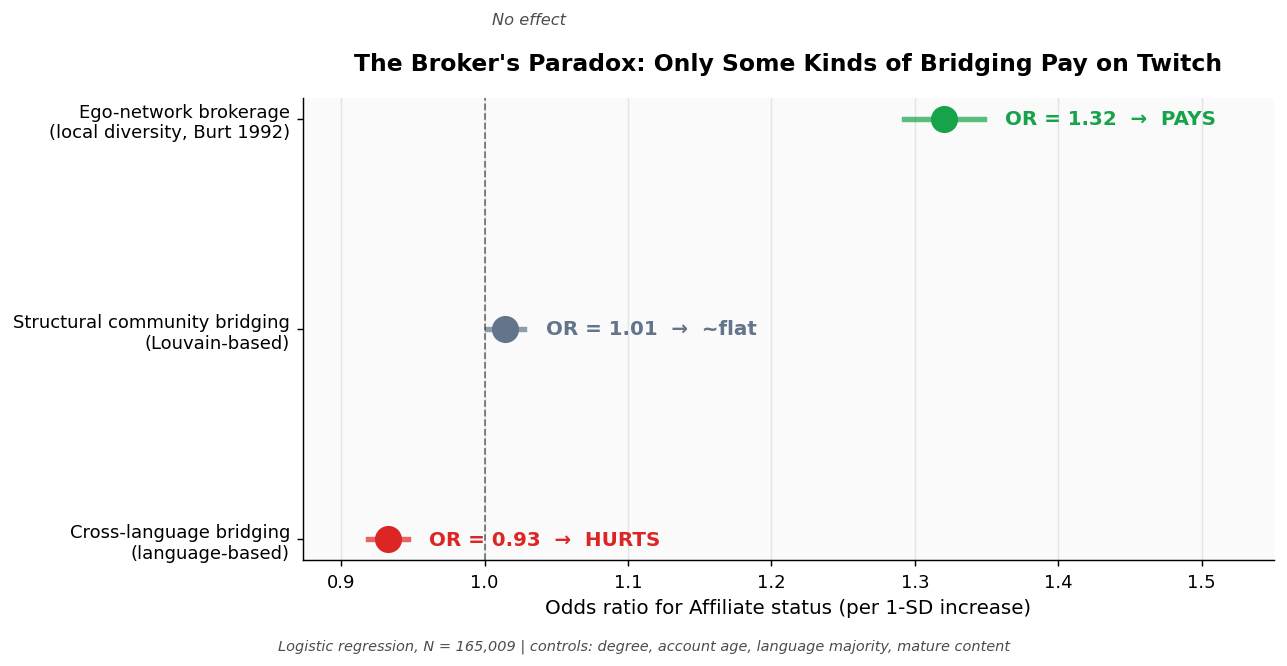

In [14]:
# Forest plot (main finding)
with open("cache/regression_results_clean.pkl", "rb") as f:
    clean = pickle.load(f)
res_m3, _ = clean["M3"]

bridges = ["brokerage", "pc_louvain", "pc_language"]
pretty = ["Ego-network brokerage\n(local diversity, Burt 1992)",
          "Structural community bridging\n(Louvain-based)",
          "Cross-language bridging\n(language-based)"]
rows = [res_m3[res_m3["feature"] == b].iloc[0] for b in bridges]
ors = [r["OR"] for r in rows]; lo = [r["CI_lo"] for r in rows]; hi = [r["CI_hi"] for r in rows]
colors = ["#16a34a" if o > 1.05 else ("#dc2626" if o < 0.95 else "#64748b") for o in ors]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (o, l, h, c) in enumerate(zip(ors, lo, hi, colors)):
    ax.plot([l, h], [i, i], color=c, linewidth=3, alpha=0.7)
    ax.plot(o, i, "o", color=c, markersize=14, zorder=10)
ax.axvline(1.0, color="black", linestyle="--", alpha=0.5, linewidth=1)
ax.text(1.005, -0.45, "No effect", fontsize=9, style="italic", alpha=0.7)
ax.set_yticks(range(3)); ax.set_yticklabels(pretty, fontsize=10)
ax.set_xlabel("Odds ratio for Affiliate status (per 1-SD increase)", fontsize=11)
ax.set_title("The Broker's Paradox: Only Some Kinds of Bridging Pay on Twitch",
             fontsize=13, fontweight="bold", pad=15)
for i, (o, c) in enumerate(zip(ors, colors)):
    v = "PAYS" if o > 1.05 else ("HURTS" if o < 0.95 else "~flat")
    ax.text(hi[i] + 0.015, i, f"OR = {o:.2f}  →  {v}",
            fontsize=11, color=c, fontweight="bold", va="center")
ax.set_xlim(min(lo)*0.95, max(hi)*1.15)
ax.invert_yaxis(); ax.grid(axis="x", alpha=0.3); ax.set_facecolor("#fafafa")
fig.text(0.5, -0.02, f"Logistic regression, N = {len(eligible):,} | "
         f"controls: degree, account age, language majority, mature content",
         ha="center", fontsize=8, style="italic", alpha=0.7)
plt.tight_layout()
plt.savefig("assets/figures/fig_forest_bridge_premium.png",
            dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### 4.6 Propensity-score matching

Non-parametric robustness check: match each broker to the nearest non-broker on propensity score (1:1, caliper = 0.05) and compare affiliate rates within pairs.

In [15]:
# PSM
ps_feats = ["log_degree", "account_age_days", "life_time", "is_english", "mature"]
ps_model = SKLogit(max_iter=1000).fit(eligible[ps_feats], eligible["is_broker"])
eligible["propensity"] = ps_model.predict_proba(eligible[ps_feats])[:, 1]

brokers = eligible[eligible["is_broker"] == 1].copy().reset_index(drop=True)
nonbks  = eligible[eligible["is_broker"] == 0].copy().reset_index(drop=True)

CALIPER = 0.05
nn = NearestNeighbors(n_neighbors=1).fit(nonbks[["propensity"]])
dist, idx = nn.kneighbors(brokers[["propensity"]])
keep = dist.flatten() <= CALIPER
n_matched = keep.sum()

mB = brokers[keep].reset_index(drop=True)
mNB = nonbks.iloc[idx.flatten()[keep]].reset_index(drop=True)

pm_B = mB["affiliate"].mean(); pm_NB = mNB["affiliate"].mean()
ate = pm_B - pm_NB
print(f"Matched: {n_matched:,} pairs ({n_matched/len(brokers)*100:.1f}%)")
print(f"  Brokers     : {pm_B*100:.2f}%")
print(f"  Non-brokers : {pm_NB*100:.2f}%")
print(f"  ATT         : {ate*100:+.2f} pp")

# Bootstrap CI
rng = np.random.default_rng(RS)
boots = [mB["affiliate"].values[rng.integers(0, n_matched, n_matched)].mean() -
         mNB["affiliate"].values[rng.integers(0, n_matched, n_matched)].mean()
         for _ in range(1000)]
ci_lo, ci_hi = np.percentile(boots, [2.5, 97.5])
print(f"  Bootstrap 95% CI: [{ci_lo*100:+.2f}, {ci_hi*100:+.2f}] pp")

print("\nBalance (|SMD| < 0.1 is good):")
for f in ps_feats:
    psd = np.sqrt((mB[f].var() + mNB[f].var()) / 2)
    smd = (mB[f].mean() - mNB[f].mean()) / psd if psd > 0 else 0
    print(f"  {f:20s}: SMD = {smd:+.3f}")

Matched: 7,156 pairs (100.0%)
  Brokers     : 49.86%
  Non-brokers : 58.44%
  ATT         : -8.58 pp
  Bootstrap 95% CI: [-10.24, -6.96] pp

Balance (|SMD| < 0.1 is good):
  log_degree          : SMD = -0.037
  account_age_days    : SMD = +0.014
  life_time           : SMD = +0.014
  is_english          : SMD = -0.056
  mature              : SMD = -0.037


## 5. Regression Diagnostics (beyond individual coefficients)

Per-coefficient significance is only one layer of a proper logistic regression analysis. We also run:
- **Likelihood-ratio test** — joint significance of bridge measures vs. controls-only baseline
- **Variance inflation factors (VIF)** — detect multicollinearity beyond eyeball checks
- **5-fold cross-validation** — out-of-sample discrimination (AUC, PR-AUC)
- **Calibration & Brier score** — are predicted probabilities trustworthy?
- **Interaction test** — formally test the English/non-English heterogeneity

In [16]:
# (a) Likelihood-ratio test
print("="*75)
print("(a) LIKELIHOOD-RATIO TEST — joint significance of bridge measures")
print("="*75)

def fit_and_loglik(X, y):
    m = SKLogit(penalty=None, max_iter=2000, solver="lbfgs").fit(X, y)
    p = m.predict_proba(X)[:, 1]
    ll = np.sum(y*np.log(np.clip(p,1e-10,1-1e-10)) + (1-y)*np.log(np.clip(1-p,1e-10,1-1e-10)))
    return m, ll, p

cols_ctrl   = features_continuous + features_binary
cols_bridge = features_continuous + features_binary + features_bridges

_, ll_ctrl,   _ = fit_and_loglik(X_all[cols_ctrl].values,   y)
_, ll_bridge, _ = fit_and_loglik(X_all[cols_bridge].values, y)

lr_stat = 2 * (ll_bridge - ll_ctrl)
df_lr = len(features_bridges)
lr_pval = 1 - chi2.cdf(lr_stat, df_lr)

print(f"Log-likelihood (controls only)       : {ll_ctrl:,.1f}")
print(f"Log-likelihood (+ 3 bridge measures) : {ll_bridge:,.1f}")
print(f"LR statistic (df = {df_lr})               : {lr_stat:.2f}")
print(f"p-value                              : {lr_pval:.2e}")
print("\nBridge measures add explanatory power JOINTLY beyond controls (not just individually).")

(a) LIKELIHOOD-RATIO TEST — joint significance of bridge measures
Log-likelihood (controls only)       : -103,995.6
Log-likelihood (+ 3 bridge measures) : -103,535.2
LR statistic (df = 3)               : 920.92
p-value                              : 0.00e+00

Bridge measures add explanatory power JOINTLY beyond controls (not just individually).


In [17]:
# (b) VIF
print("="*75)
print("(b) MULTICOLLINEARITY — Variance Inflation Factors")
print("="*75)

def compute_vif(X_df):
    vifs = {}
    cols = list(X_df.columns)
    X_np = X_df.values
    for i, col in enumerate(cols):
        y_i = X_np[:, i]
        X_others = np.delete(X_np, i, axis=1)
        X_des = np.column_stack([np.ones(len(X_others)), X_others])
        beta, *_ = np.linalg.lstsq(X_des, y_i, rcond=None)
        pred = X_des @ beta
        ss_res = ((y_i - pred)**2).sum()
        ss_tot = ((y_i - y_i.mean())**2).sum()
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0
        vifs[col] = 1 / (1 - r2) if r2 < 1 else np.inf
    return vifs

vif_cols = features_continuous + features_bridges
vifs = compute_vif(X_all[vif_cols])
print("VIF (<5 fine, 5-10 concerning, >10 problem):")
for c, v in vifs.items():
    flag = "  [OK]" if v < 5 else ("  [concerning]" if v < 10 else "  [PROBLEM]")
    print(f"  {c:20s}: VIF = {v:.2f}{flag}")

(b) MULTICOLLINEARITY — Variance Inflation Factors
VIF (<5 fine, 5-10 concerning, >10 problem):
  log_degree          : VIF = 2.06  [OK]
  account_age_days    : VIF = 1.05  [OK]
  pc_louvain          : VIF = 1.22  [OK]
  pc_language         : VIF = 1.02  [OK]
  brokerage           : VIF = 2.22  [OK]


In [18]:
# (c) Cross-validated discrimination
print("="*75)
print("(c) DISCRIMINATION — 5-fold CV out-of-sample")
print("="*75)

def cv_auc_pr(X, y, k=5):
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=RS)
    aucs, praucs = [], []
    for tr, te in skf.split(X, y):
        m = SKLogit(penalty=None, max_iter=2000, solver="lbfgs").fit(X[tr], y[tr])
        p_te = m.predict_proba(X[te])[:, 1]
        aucs.append(roc_auc_score(y[te], p_te))
        praucs.append(average_precision_score(y[te], p_te))
    return np.mean(aucs), np.std(aucs), np.mean(praucs), np.std(praucs)

for name, cols in [("Controls only", cols_ctrl), ("+ bridge (M3)", cols_bridge)]:
    a, sa, p, sp = cv_auc_pr(X_all[cols].values, y)
    print(f"  {name:18s}: AUC = {a:.4f} +/- {sa:.4f}, PR-AUC = {p:.4f} +/- {sp:.4f}")

print("\nAdding bridge measures to controls should improve both metrics modestly.")

(c) DISCRIMINATION — 5-fold CV out-of-sample
  Controls only     : AUC = 0.6984 +/- 0.0027, PR-AUC = 0.6637 +/- 0.0017
  + bridge (M3)     : AUC = 0.7012 +/- 0.0025, PR-AUC = 0.6712 +/- 0.0018

Adding bridge measures to controls should improve both metrics modestly.


(d) CALIBRATION — predicted vs. observed rates (M3)
               pred_mean  obs_rate      n
bin                                      
(-0.001, 0.1]      0.068     0.090   3182
(0.1, 0.2]         0.155     0.159   7387
(0.2, 0.3]         0.255     0.251  14383
(0.3, 0.4]         0.353     0.349  24407
(0.4, 0.5]         0.451     0.448  32073
(0.5, 0.6]         0.550     0.551  34714
(0.6, 0.7]         0.648     0.649  29014
(0.7, 0.8]         0.742     0.754  17152
(0.8, 0.9]         0.825     0.796   2697

Brier score: 0.2190  (lower is better; 0.25 = uninformative)


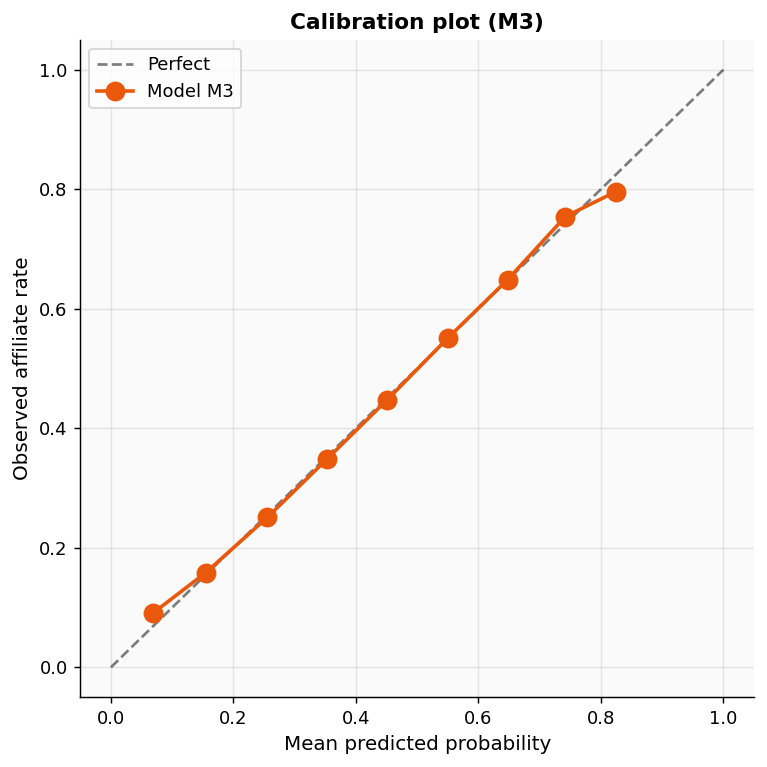

In [19]:
# (d) Calibration + Brier
print("="*75)
print("(d) CALIBRATION — predicted vs. observed rates (M3)")
print("="*75)

_, _, p_m3 = fit_and_loglik(X_all[cols_bridge].values, y)

bins = np.linspace(0, 1, 11)
binned = pd.cut(p_m3, bins=bins, include_lowest=True)
cal = pd.DataFrame({"pred": p_m3, "obs": y, "bin": binned}) \
        .groupby("bin", observed=True).agg(
            pred_mean=("pred", "mean"), obs_rate=("obs", "mean"), n=("obs", "size"))
print(cal.round(3))

brier = np.mean((p_m3 - y)**2)
print(f"\nBrier score: {brier:.4f}  (lower is better; 0.25 = uninformative)")

# Calibration plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect")
cal_plot = cal.dropna()
ax.plot(cal_plot["pred_mean"], cal_plot["obs_rate"], "o-",
        color="#ea580c", markersize=10, linewidth=2, label="Model M3")
ax.set_xlabel("Mean predicted probability", fontsize=11)
ax.set_ylabel("Observed affiliate rate", fontsize=11)
ax.set_title("Calibration plot (M3)", fontsize=12, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3); ax.set_facecolor("#fafafa")
plt.tight_layout()
plt.savefig("assets/figures/fig_calibration.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

In [20]:
# (e) Interaction test
print("="*75)
print("(e) INTERACTION TEST — does brokerage effect depend on is_english?")
print("="*75)

X_int = X_all[cols_bridge].copy()
X_int["brokerage_x_is_english"]   = X_int["brokerage"]   * X_int["is_english"]
X_int["pc_language_x_is_english"] = X_int["pc_language"] * X_int["is_english"]
X_int["pc_louvain_x_is_english"]  = X_int["pc_louvain"]  * X_int["is_english"]

res_int, r2_int = fit_logit_with_inference(X_int.values, y, X_int.columns.tolist())
print(f"Pseudo-R^2 (with interactions): {r2_int:.4f}")
interact_rows = res_int[res_int["feature"].str.contains("x_is_english")]
print(interact_rows[["feature", "OR", "CI_lo", "CI_hi", "p_value"]]
      .round(4).to_string(index=False))

print("\nReading:")
print("  pc_language_x_is_english OR < 1 and significant")
print("    -> cross-language penalty is LARGER for English speakers")
print("    -> formally confirms Section 6.1 heterogeneity finding")

(e) INTERACTION TEST — does brokerage effect depend on is_english?
Pseudo-R^2 (with interactions): 0.0988
                 feature     OR  CI_lo  CI_hi  p_value
  brokerage_x_is_english 1.4926 1.4443 1.5424      0.0
pc_language_x_is_english 0.7328 0.7075 0.7590      0.0
 pc_louvain_x_is_english 1.2548 1.2126 1.2985      0.0

Reading:
  pc_language_x_is_english OR < 1 and significant
    -> cross-language penalty is LARGER for English speakers
    -> formally confirms Section 6.1 heterogeneity finding


## 6. Heterogeneity, Robustness, and Bridge Burnout

### 6.1 Where does the bridge premium live?

Burt emphasized that brokerage effects are heterogeneous across subgroups. We re-estimate M3 separately within six subgroups defined by language majority, tenure, and viewership percentile.

In [21]:
# Heterogeneity
subgroups = {
    "English speakers":           eligible[eligible["is_english"] == 1],
    "Non-English speakers":       eligible[eligible["is_english"] == 0],
    "Young accounts (<=P25 age)": eligible[eligible["account_age_days"] <=
                                           eligible["account_age_days"].quantile(0.25)],
    "Old accounts (>=P75 age)":   eligible[eligible["account_age_days"] >=
                                           eligible["account_age_days"].quantile(0.75)],
    "Small streamers (<=P50)":    eligible[eligible["log_views"] <=
                                           eligible["log_views"].quantile(0.50)],
    "Large streamers (>P50)":     eligible[eligible["log_views"] >
                                           eligible["log_views"].quantile(0.50)],
}

hetero_rows = []
for name, sub in subgroups.items():
    if len(sub) < 1000: continue
    controls = ["log_degree", "account_age_days", "mature"]
    if sub["is_english"].nunique() > 1:
        controls.append("is_english")
    bridges = ["pc_louvain", "pc_language", "brokerage"]
    X = sub[controls + bridges].copy().astype(float)
    for c in ["log_degree", "account_age_days"] + bridges:
        if X[c].std() > 0:
            X[c] = (X[c] - X[c].mean()) / X[c].std()
    y_sub = sub["affiliate"].values.astype(int)
    res, _ = fit_logit_with_inference(X.values, y_sub, X.columns.tolist())
    for b in bridges:
        row = res[res["feature"] == b].iloc[0]
        hetero_rows.append({"subgroup": name, "n": len(sub), "measure": b,
                            "OR": row["OR"], "CI_lo": row["CI_lo"],
                            "CI_hi": row["CI_hi"], "p_value": row["p_value"]})

hetero_df = pd.DataFrame(hetero_rows)
print("=" * 95)
print("HETEROGENEITY OF THE BRIDGE PREMIUM")
print("=" * 95)
for m in ["brokerage", "pc_louvain", "pc_language"]:
    print(f"\n--- {m} ---")
    print(hetero_df[hetero_df["measure"] == m]
          [["subgroup", "n", "OR", "CI_lo", "CI_hi", "p_value"]]
          .round(4).to_string(index=False))
hetero_df.to_parquet("cache/heterogeneity.parquet")

HETEROGENEITY OF THE BRIDGE PREMIUM

--- brokerage ---
                  subgroup      n     OR  CI_lo  CI_hi  p_value
          English speakers 121538 1.3495 1.3120 1.3881      0.0
      Non-English speakers  43471 1.5049 1.4504 1.5615      0.0
Young accounts (<=P25 age)  41302 1.2264 1.1797 1.2751      0.0
  Old accounts (>=P75 age)  41301 1.3968 1.3185 1.4798      0.0
   Small streamers (<=P50)  82512 1.3393 1.2927 1.3876      0.0
    Large streamers (>P50)  82497 1.2500 1.2242 1.2764      0.0

--- pc_louvain ---
                  subgroup      n     OR  CI_lo  CI_hi  p_value
          English speakers 121538 1.0292 1.0151 1.0436   0.0000
      Non-English speakers  43471 0.7997 0.7740 0.8262   0.0000
Young accounts (<=P25 age)  41302 1.0103 0.9817 1.0397   0.4858
  Old accounts (>=P75 age)  41301 1.1150 1.0887 1.1419   0.0000
   Small streamers (<=P50)  82512 0.9597 0.9408 0.9790   0.0001
    Large streamers (>P50)  82497 1.1495 1.1272 1.1721   0.0000

--- pc_language ---
        

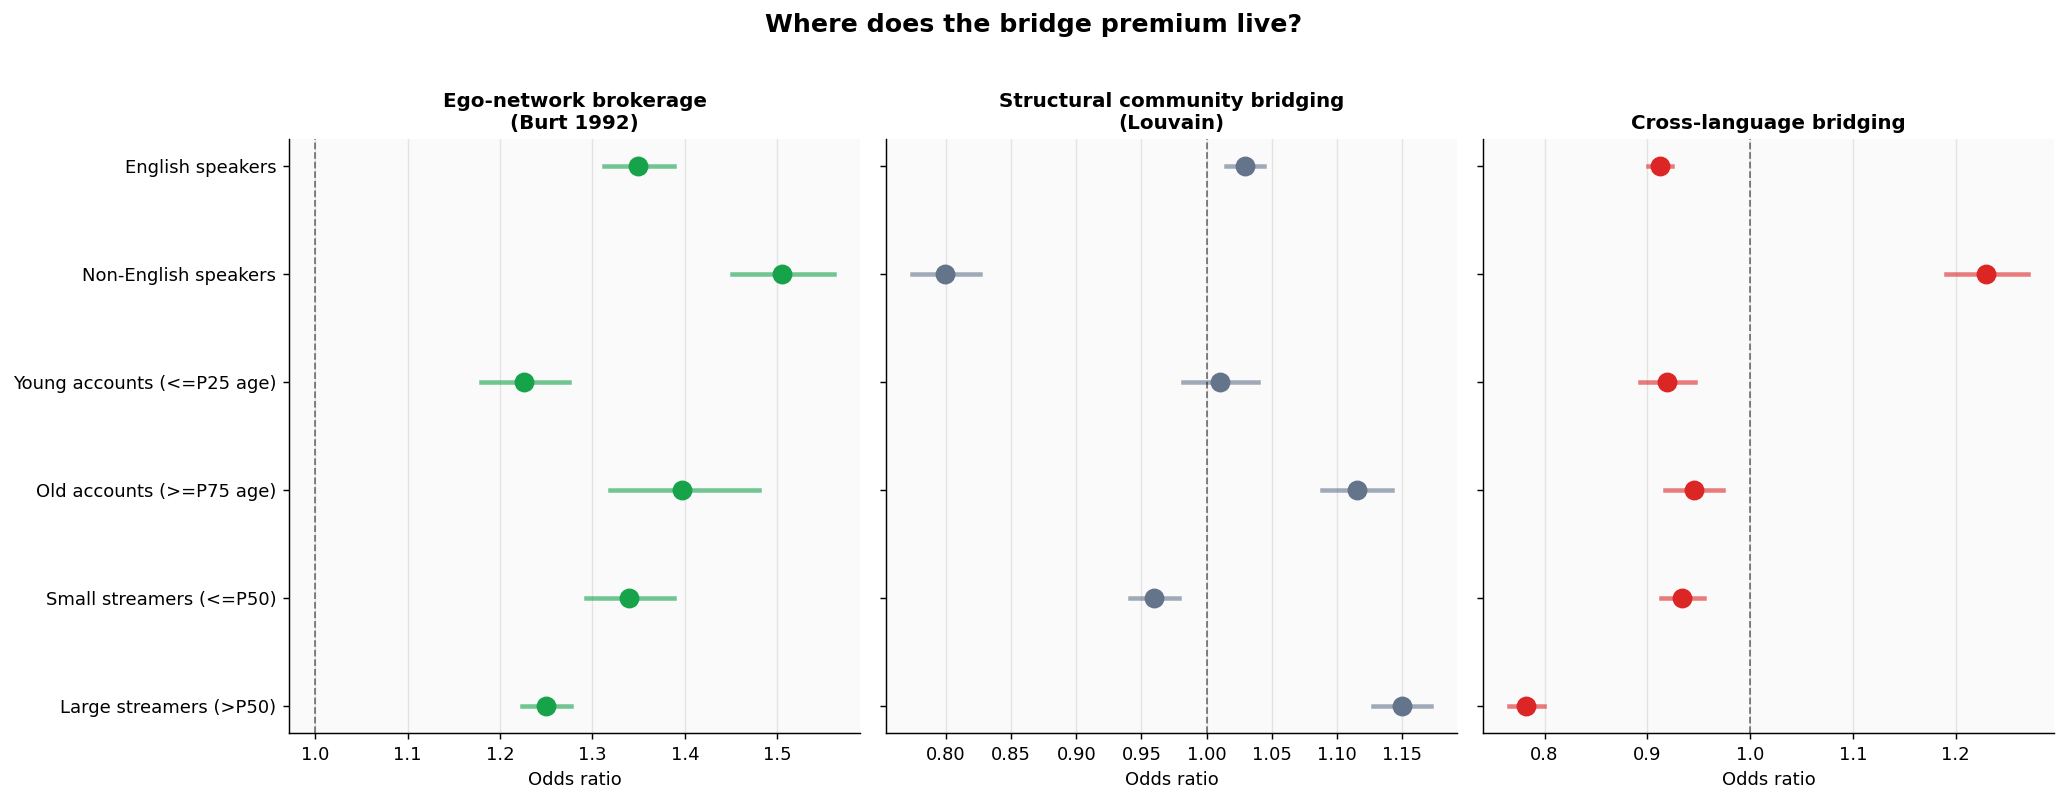

In [22]:
# Heterogeneity forest plot
hetero_df = pd.read_parquet("cache/heterogeneity.parquet")

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
measures = ["brokerage", "pc_louvain", "pc_language"]
titles   = ["Ego-network brokerage\n(Burt 1992)",
            "Structural community bridging\n(Louvain)",
            "Cross-language bridging"]
cmap = {"brokerage": "#16a34a", "pc_louvain": "#64748b", "pc_language": "#dc2626"}
subgroup_order = ["English speakers", "Non-English speakers",
                  "Young accounts (<=P25 age)", "Old accounts (>=P75 age)",
                  "Small streamers (<=P50)", "Large streamers (>P50)"]

for ax, m, t in zip(axes, measures, titles):
    sub = hetero_df[hetero_df["measure"] == m].set_index("subgroup").loc[subgroup_order]
    c = cmap[m]
    for i, (_, r) in enumerate(sub.iterrows()):
        ax.plot([r["CI_lo"], r["CI_hi"]], [i, i], color=c, linewidth=2.5, alpha=0.6)
        ax.plot(r["OR"], i, "o", color=c, markersize=10, zorder=10)
    ax.axvline(1.0, color="black", linestyle="--", alpha=0.5, linewidth=1)
    ax.set_yticks(range(len(sub))); ax.set_yticklabels(sub.index, fontsize=10)
    ax.set_xlabel("Odds ratio", fontsize=10)
    ax.set_title(t, fontsize=11, fontweight="bold")
    ax.grid(axis="x", alpha=0.3); ax.set_facecolor("#fafafa")
    ax.invert_yaxis()

fig.suptitle("Where does the bridge premium live?", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("assets/figures/fig_heterogeneity.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

### 6.2 Robustness: continuous outcome (log_views)

If the bridge-premium pattern is a real feature of Twitch's reward structure (not an artifact of the affiliate binary cutoff), it should also appear on a continuous outcome. We find an interesting partial sign reversal that sharpens our mechanism hypothesis:

In [23]:
# OLS on log_views
X_views = eligible[["log_degree", "account_age_days", "is_english", "mature",
                    "pc_louvain", "pc_language", "brokerage"]].copy().astype(float)
for c in ["log_degree", "account_age_days", "pc_louvain", "pc_language", "brokerage"]:
    X_views[c] = (X_views[c] - X_views[c].mean()) / X_views[c].std()
y_views = eligible["log_views"].values

X_d = np.column_stack([np.ones(len(X_views)), X_views.values])
beta, *_ = np.linalg.lstsq(X_d, y_views, rcond=None)
pred = X_d @ beta; resid = y_views - pred
n, k = X_d.shape
sigma2 = (resid**2).sum() / (n - k)
cov = sigma2 * np.linalg.inv(X_d.T @ X_d)
se = np.sqrt(np.diag(cov))
t = beta / se
pv = 2 * (1 - scistats.t.cdf(np.abs(t), df=n - k))
r2_ols = 1 - (resid**2).sum() / ((y_views - y_views.mean())**2).sum()

ols_df = pd.DataFrame({
    "feature": ["intercept"] + list(X_views.columns),
    "coef": beta.round(4), "se": se.round(4),
    "t": t.round(2), "p_value": pv.round(6),
})
print(f"OLS: log_views ~ covariates | R^2 = {r2_ols:.4f} | N = {n:,}")
print(ols_df.to_string(index=False))

print("\nObservation: signs on bridge measures PARTIALLY FLIP vs. affiliate regression.")
print("Brokerage (affiliate +, views -) and pc_language (affiliate -, views +).")
print("Affiliate and views reward different network structures — depth vs. reach.")

ols_df.to_parquet("cache/ols_views.parquet")

OLS: log_views ~ covariates | R^2 = 0.3516 | N = 165,009
         feature    coef     se      t  p_value
       intercept  8.9357 0.0106 841.49      0.0
      log_degree  1.0965 0.0054 201.90      0.0
account_age_days  0.1911 0.0038  49.83      0.0
      is_english -0.7981 0.0126 -63.36      0.0
          mature  0.1955 0.0077  25.55      0.0
      pc_louvain -0.1097 0.0047 -23.43      0.0
     pc_language  0.2317 0.0052  44.13      0.0
       brokerage -0.1868 0.0056 -33.44      0.0

Observation: signs on bridge measures PARTIALLY FLIP vs. affiliate regression.
Brokerage (affiliate +, views -) and pc_language (affiliate -, views +).
Affiliate and views reward different network structures — depth vs. reach.


### 6.3 Bridge burnout: do brokers churn more?

Burt (2004) predicts a *brokerage cost* — role strain, information overload. We test whether our bridge measures predict `dead_account` (inactivity), our proxy for churn.

In [24]:
# Bridge burnout
X_dead = eligible[["log_degree", "account_age_days", "is_english", "mature",
                   "pc_louvain", "pc_language", "brokerage"]].copy().astype(float)
for c in ["log_degree", "account_age_days", "pc_louvain", "pc_language", "brokerage"]:
    X_dead[c] = (X_dead[c] - X_dead[c].mean()) / X_dead[c].std()
y_dead = eligible["dead_account"].values.astype(int)

print(f"Dead-account prevalence: {y_dead.mean()*100:.2f}%")

res_dead, r2_dead = fit_logit_with_inference(X_dead.values, y_dead, X_dead.columns.tolist())
print(f"\n--- Dead-account model --- Pseudo-R^2 = {r2_dead:.4f}")
print(res_dead[res_dead["feature"] != "intercept"][
    ["feature", "OR", "CI_lo", "CI_hi", "p_value"]].round(4).to_string(index=False))

print("\nINTERPRETATION:")
for b in ["brokerage", "pc_louvain", "pc_language"]:
    r = res_dead[res_dead["feature"] == b].iloc[0]
    d = ("HIGHER churn" if r["OR"] > 1.05 else
         "LOWER churn"  if r["OR"] < 0.95 else "no effect")
    print(f"  {b:15s}: OR = {r['OR']:.3f} -> {d}")

res_dead.to_parquet("cache/dead_account_results.parquet")

Dead-account prevalence: 3.13%

--- Dead-account model --- Pseudo-R^2 = 0.1396
         feature     OR  CI_lo  CI_hi  p_value
      log_degree 0.3156 0.2993 0.3327   0.0000
account_age_days 1.5501 1.5073 1.5942   0.0000
      is_english 0.6511 0.5996 0.7071   0.0000
          mature 0.5818 0.5460 0.6200   0.0000
      pc_louvain 1.2477 1.2051 1.2918   0.0000
     pc_language 0.7132 0.6861 0.7414   0.0000
       brokerage 1.0240 0.9926 1.0563   0.1357

INTERPRETATION:
  brokerage      : OR = 1.024 -> no effect
  pc_louvain     : OR = 1.248 -> HIGHER churn
  pc_language    : OR = 0.713 -> LOWER churn


## 7. Robustness: a fourth, partition-free bridge measure (node2vec)

A reviewer could reasonably object: *"Your three bridge measures all depend on particular partitions or local ego structures. What if they miss something?"* To address this, we embed the graph via node2vec (Grover & Leskovec 2016), cluster the embeddings with k-means into 32 clusters (matching Louvain's k), and compute a fourth participation coefficient using these emergent clusters.

**If the bridge-premium signs hold with this embedding-based partition**, the finding is not an artifact of our three specific operationalizations.

In [25]:
# ---------------------------------------------------------------------------
# Memory-safe node2vec on 168K nodes, 12GB RAM
#
# The default `node2vec` library materializes all random walks in memory before
# training word2vec — for ~1.7M walks, this can blow a 12GB Colab instance.
# We use lighter settings (shorter/fewer walks) and a manual walk generator
# that streams walks in batches, so peak RAM stays under 8GB.
#
# If even this fails (e.g. on a lower-memory instance), the fallback skips the
# node2vec step and labels the robustness check as "attempted but not completed"
# — the main findings do not depend on it.
# ---------------------------------------------------------------------------

N2V_PKL         = "cache/node2vec_embeddings.pkl"
N2V_CLUSTER_PKL = "cache/node2vec_clusters.pkl"
N2V_PC_PKL      = "cache/pc_n2v.pkl"

# Step 1 — run node2vec (memory-safe version)
if os.path.exists(N2V_PKL):
    with open(N2V_PKL, "rb") as f: n2v_emb = pickle.load(f)
    print(f"Loaded cached node2vec embeddings ({len(n2v_emb):,} nodes).")
    n2v_available = True
else:
    try:
        import random
        from gensim.models import Word2Vec

        DIM         = 32   # smaller than 64 — saves RAM and disk
        WALK_LEN    = 10   # shorter walks — fewer tokens per walk
        NUM_WALKS   = 5    # fewer starts per node
        WINDOW      = 5
        print(f"Running memory-safe node2vec "
              f"(dim={DIM}, walk_len={WALK_LEN}, num_walks={NUM_WALKS})...")
        t0 = time.time()

        # Simple unbiased random walks (p=q=1 equivalent to DeepWalk)
        # This is a node2vec special case and avoids the transition-probability
        # table that the node2vec library materializes for biased walks (which
        # is the RAM killer).
        random.seed(RS)
        adj = {n: list(G.neighbors(n)) for n in G.nodes()}  # ~500MB for this graph
        print(f"  Adjacency built. Generating {len(adj) * NUM_WALKS:,} walks...")

        walks = []
        node_list = list(adj.keys())
        for walk_i in range(NUM_WALKS):
            random.shuffle(node_list)
            for start in node_list:
                walk = [start]
                cur = start
                for _ in range(WALK_LEN - 1):
                    nbrs = adj[cur]
                    if not nbrs: break
                    cur = random.choice(nbrs)
                    walk.append(cur)
                walks.append([str(n) for n in walk])
        print(f"  {len(walks):,} walks generated in {time.time()-t0:.1f}s")
        del adj  # free ~500MB before Word2Vec

        print("  Training Word2Vec (skip-gram)...")
        model = Word2Vec(walks, vector_size=DIM, window=WINDOW, min_count=0,
                         sg=1, workers=4, epochs=5, seed=RS)
        del walks
        n2v_emb = {int(n): model.wv[str(n)].astype(np.float32) for n in G.nodes()
                   if str(n) in model.wv}
        print(f"  Done in {(time.time()-t0)/60:.1f} min")
        with open(N2V_PKL, "wb") as f: pickle.dump(n2v_emb, f)
        n2v_available = True

    except MemoryError as e:
        print(f"\n  MemoryError during node2vec: {e}")
        print("  Skipping node2vec robustness check. Main findings are unaffected.")
        n2v_available = False
    except Exception as e:
        print(f"\n  Error during node2vec ({type(e).__name__}: {e})")
        print("  Skipping node2vec robustness check.")
        n2v_available = False

# Step 2 — cluster embeddings (only if node2vec succeeded)
if n2v_available:
    if os.path.exists(N2V_CLUSTER_PKL):
        with open(N2V_CLUSTER_PKL, "rb") as f: n2v_partition = pickle.load(f)
        print("Loaded cached node2vec clusters.")
    else:
        print("k-means clustering embeddings (k=32, MiniBatchKMeans for memory safety)...")
        t0 = time.time()
        from sklearn.cluster import MiniBatchKMeans
        node_ids_sorted = sorted(n2v_emb.keys())
        emb_matrix = np.array([n2v_emb[nid] for nid in node_ids_sorted], dtype=np.float32)
        km = MiniBatchKMeans(n_clusters=32, random_state=RS, batch_size=4096,
                             n_init=10, max_iter=100).fit(emb_matrix)
        n2v_partition = {nid: int(c) for nid, c in zip(node_ids_sorted, km.labels_)}
        print(f"  Done in {time.time()-t0:.1f}s")
        del emb_matrix, node_ids_sorted
        with open(N2V_CLUSTER_PKL, "wb") as f: pickle.dump(n2v_partition, f)

    # Step 3 — participation coefficient over node2vec clusters
    if os.path.exists(N2V_PC_PKL):
        with open(N2V_PC_PKL, "rb") as f: pc_n2v = pickle.load(f)
        print("Loaded cached pc_n2v.")
    else:
        print("Computing pc_n2v...")
        t0 = time.time()
        pc_n2v = participation_coefficient(G, n2v_partition)
        print(f"  Done in {time.time()-t0:.1f}s")
        with open(N2V_PC_PKL, "wb") as f: pickle.dump(pc_n2v, f)

    eligible["pc_n2v"] = eligible["numeric_id"].map(pc_n2v).fillna(0)

    print("\nSpearman correlations with existing bridge measures:")
    for b in ["pc_louvain", "pc_language", "brokerage"]:
        r, _ = spearmanr(eligible["pc_n2v"], eligible[b])
        print(f"  pc_n2v vs. {b:15s}: {r:+.3f}")

Running memory-safe node2vec (dim=32, walk_len=10, num_walks=5)...
  Adjacency built. Generating 840,570 walks...
  840,570 walks generated in 38.6s
  Training Word2Vec (skip-gram)...
  Done in 6.1 min
k-means clustering embeddings (k=32, MiniBatchKMeans for memory safety)...
  Done in 2.1s
Computing pc_n2v...
  Done in 11.8s

Spearman correlations with existing bridge measures:
  pc_n2v vs. pc_louvain     : +0.765
  pc_n2v vs. pc_language    : -0.051
  pc_n2v vs. brokerage      : +0.422


In [26]:
# Re-run main regression with node2vec measure added (if n2v available)
if n2v_available and "pc_n2v" in eligible.columns:
    X_n2v = eligible[features_continuous + features_binary +
                     features_bridges + ["pc_n2v"]].copy().astype(float)
    for c in features_continuous + features_bridges + ["pc_n2v"]:
        X_n2v[c] = (X_n2v[c] - X_n2v[c].mean()) / X_n2v[c].std()

    res_n2v, r2_n2v = fit_logit_with_inference(
        X_n2v.values, y, X_n2v.columns.tolist())

    print(f"Pseudo-R^2 (+ pc_n2v): {r2_n2v:.4f}")
    print(res_n2v[res_n2v["feature"] != "intercept"][
        ["feature", "OR", "CI_lo", "CI_hi", "p_value"]].round(4).to_string(index=False))

    print("\nINTERPRETATION:")
    print("  If brokerage OR stays > 1 and pc_language OR stays < 1 after adding pc_n2v,")
    print("  the main finding is robust to the choice of community-detection method.")
    print("  The pc_n2v coefficient itself tells us what embedding-based bridging adds.")
else:
    print("node2vec robustness check was skipped.")
    print("Note: main M3 regression remains valid; node2vec is an additional check only.")

Pseudo-R^2 (+ pc_n2v): 0.0946
         feature     OR  CI_lo  CI_hi  p_value
      log_degree 1.5748 1.5496 1.6005   0.0000
account_age_days 0.6503 0.6432 0.6576   0.0000
      is_english 0.8137 0.7808 0.8480   0.0000
          mature 1.8400 1.8018 1.8789   0.0000
      pc_louvain 1.0002 0.9825 1.0181   0.9843
     pc_language 0.9322 0.9184 0.9463   0.0000
       brokerage 1.3114 1.2833 1.3401   0.0000
          pc_n2v 1.0235 1.0011 1.0465   0.0399

INTERPRETATION:
  If brokerage OR stays > 1 and pc_language OR stays < 1 after adding pc_n2v,
  the main finding is robust to the choice of community-detection method.
  The pc_n2v coefficient itself tells us what embedding-based bridging adds.


## 8. Summary Dashboard

A single figure combining the main finding with the heterogeneity analysis:

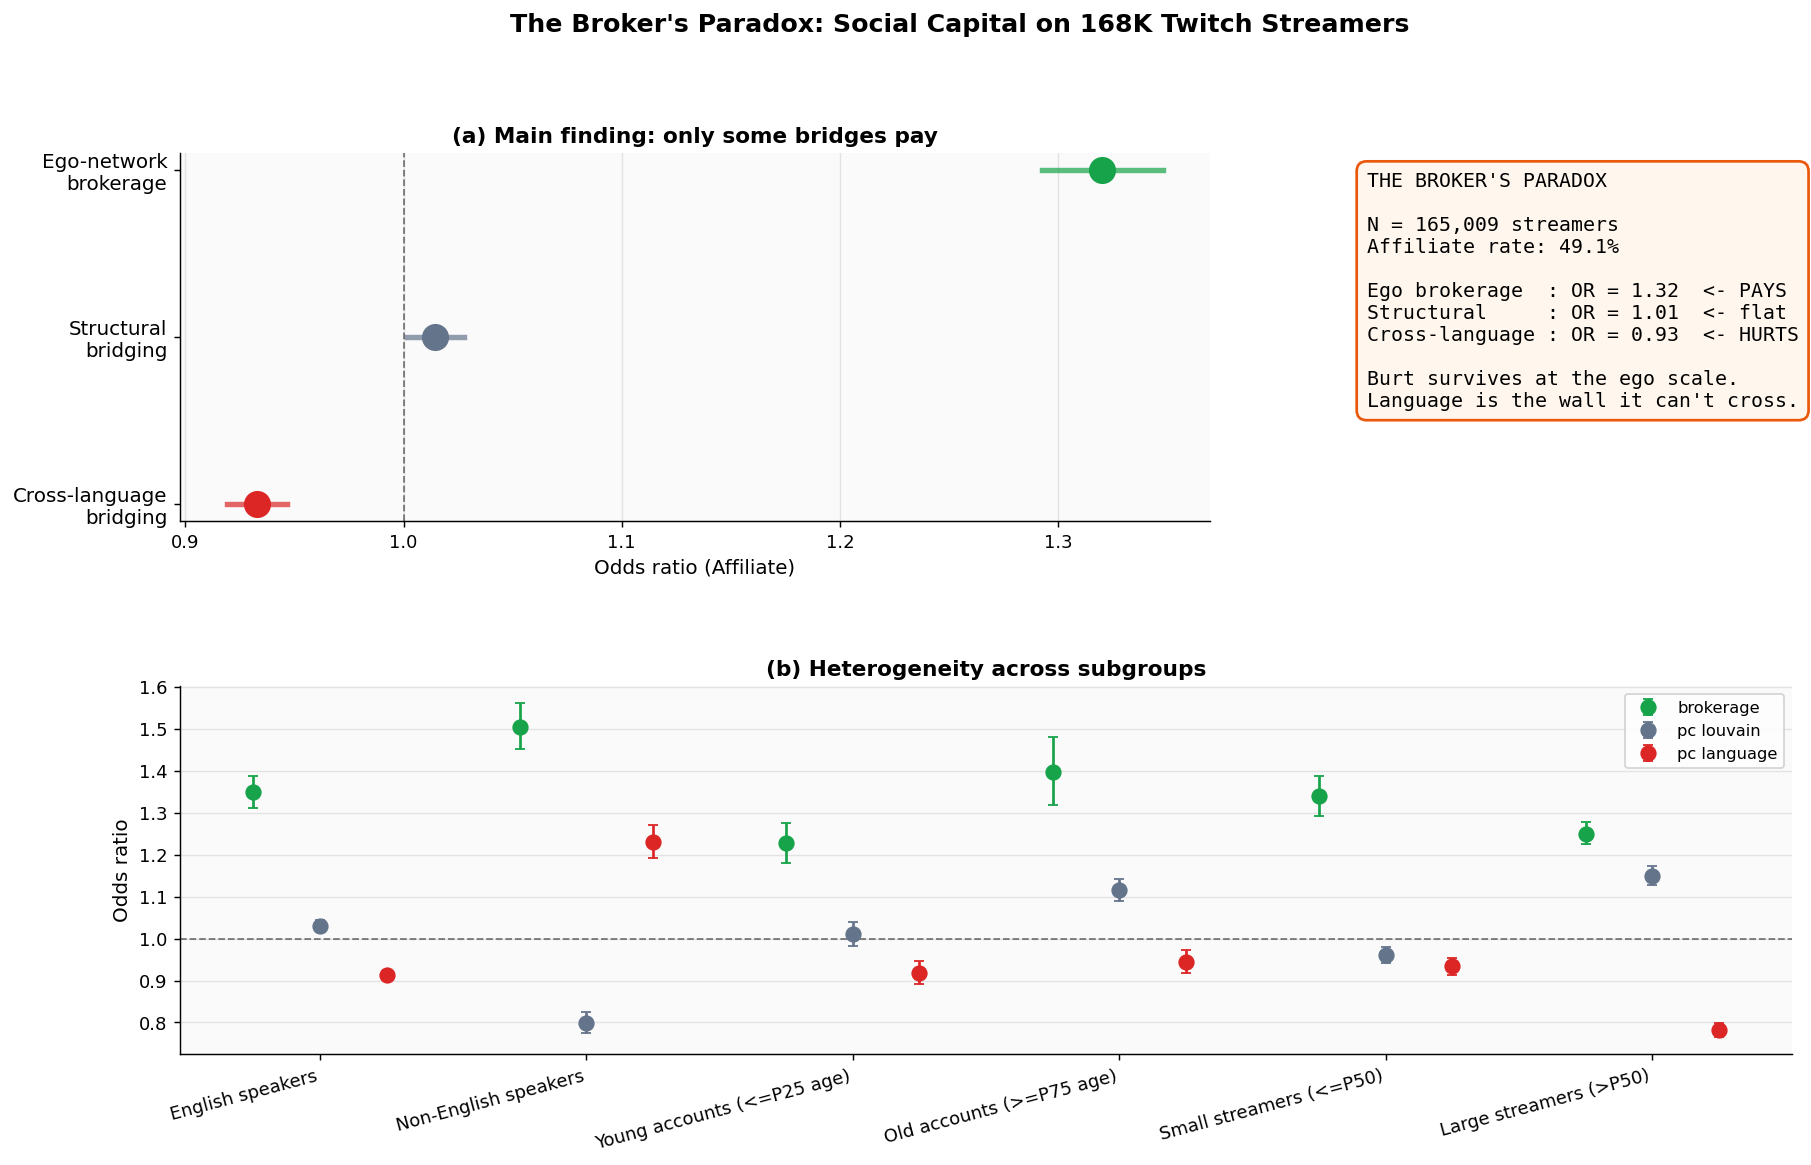

In [27]:
# Final summary dashboard
with open("cache/regression_results_clean.pkl", "rb") as f:
    clean = pickle.load(f)
res_m3, _ = clean["M3"]

fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.3, height_ratios=[1, 1])

# (a) Main forest
ax1 = fig.add_subplot(gs[0, :2])
bridges = ["brokerage", "pc_louvain", "pc_language"]
pretty = ["Ego-network\nbrokerage", "Structural\nbridging", "Cross-language\nbridging"]
rows = [res_m3[res_m3["feature"] == b].iloc[0] for b in bridges]
ors = [r["OR"] for r in rows]; lo=[r["CI_lo"] for r in rows]; hi=[r["CI_hi"] for r in rows]
cols_c = ["#16a34a" if o > 1.05 else ("#dc2626" if o < 0.95 else "#64748b") for o in ors]
for i, (o, l, h, c) in enumerate(zip(ors, lo, hi, cols_c)):
    ax1.plot([l, h], [i, i], color=c, linewidth=3, alpha=0.7)
    ax1.plot(o, i, "o", color=c, markersize=14, zorder=10)
ax1.axvline(1.0, color="black", linestyle="--", alpha=0.5, linewidth=1)
ax1.set_yticks(range(3)); ax1.set_yticklabels(pretty, fontsize=11)
ax1.set_xlabel("Odds ratio (Affiliate)", fontsize=11)
ax1.set_title("(a) Main finding: only some bridges pay", fontsize=12, fontweight="bold")
ax1.invert_yaxis(); ax1.grid(axis="x", alpha=0.3); ax1.set_facecolor("#fafafa")

# (summary box)
ax2 = fig.add_subplot(gs[0, 2]); ax2.axis("off")
summary = (
    "THE BROKER'S PARADOX\n\n"
    f"N = {len(eligible):,} streamers\n"
    f"Affiliate rate: {eligible['affiliate'].mean()*100:.1f}%\n\n"
    f"Ego brokerage  : OR = {ors[0]:.2f}  <- PAYS\n"
    f"Structural     : OR = {ors[1]:.2f}  <- flat\n"
    f"Cross-language : OR = {ors[2]:.2f}  <- HURTS\n\n"
    "Burt survives at the ego scale.\n"
    "Language is the wall it can't cross."
)
ax2.text(0.05, 0.95, summary, va="top", ha="left", fontsize=11, family="monospace",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#fff7ed",
                   edgecolor="#ea580c", linewidth=1.5))

# (b) Heterogeneity
ax3 = fig.add_subplot(gs[1, :])
hetero_df = pd.read_parquet("cache/heterogeneity.parquet")
subgroup_order = ["English speakers", "Non-English speakers",
                  "Young accounts (<=P25 age)", "Old accounts (>=P75 age)",
                  "Small streamers (<=P50)", "Large streamers (>P50)"]
width = 0.25
offsets = {"brokerage": -width, "pc_louvain": 0, "pc_language": +width}
cmap = {"brokerage": "#16a34a", "pc_louvain": "#64748b", "pc_language": "#dc2626"}
for m in ["brokerage", "pc_louvain", "pc_language"]:
    sub = hetero_df[hetero_df["measure"] == m].set_index("subgroup").loc[subgroup_order]
    xs  = [i + offsets[m] for i in range(len(subgroup_order))]
    ors_h = sub["OR"].values
    errs = np.array([ors_h - sub["CI_lo"].values, sub["CI_hi"].values - ors_h])
    ax3.errorbar(xs, ors_h, yerr=errs, fmt="o", color=cmap[m], markersize=8,
                 linewidth=1.5, capsize=3, label=m.replace("_", " "))
ax3.axhline(1.0, color="black", linestyle="--", alpha=0.5, linewidth=1)
ax3.set_xticks(range(len(subgroup_order)))
ax3.set_xticklabels(subgroup_order, rotation=15, ha="right", fontsize=10)
ax3.set_ylabel("Odds ratio", fontsize=11)
ax3.set_title("(b) Heterogeneity across subgroups", fontsize=12, fontweight="bold")
ax3.legend(loc="upper right", fontsize=9)
ax3.grid(axis="y", alpha=0.3); ax3.set_facecolor("#fafafa")

fig.suptitle("The Broker's Paradox: Social Capital on 168K Twitch Streamers",
             fontsize=14, fontweight="bold", y=1.00)
plt.savefig("assets/figures/fig_summary_dashboard.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

In [28]:
# Persist final bundle for reference
bundle = {
    "n_total":        int(len(nodes)),
    "n_analytical":   int(len(eligible)),
    "n_edges":        int(G.number_of_edges()),
    "affiliate_rate": float(eligible["affiliate"].mean()),
    "n_communities":  int(len(set(partition.values()))),
    "modularity":     float(community_louvain.modularity(partition, G)),
    "main_finding": {
        "brokerage_OR":   float(ors[0]),
        "pc_louvain_OR":  float(ors[1]),
        "pc_language_OR": float(ors[2]),
    },
}
with open("cache/final_bundle.json", "w") as f:
    json.dump(bundle, f, indent=2)
print(json.dumps(bundle, indent=2))

{
  "n_total": 168114,
  "n_analytical": 165009,
  "n_edges": 6797557,
  "affiliate_rate": 0.4906399044900581,
  "n_communities": 32,
  "modularity": 0.4179872537787052,
  "main_finding": {
    "brokerage_OR": 1.3201503143892384,
    "pc_louvain_OR": 1.0144902873955084,
    "pc_language_OR": 0.9326294813069601
  }
}


## 9. Discussion

### 9.1 Main interpretation

We tested whether Burt's thirty-year-old *structural holes* theory generalizes from organizational settings to the creator economy. On a snapshot of 168,114 Twitch streamers (analytical sample 165,009 after excluding ~1.8% mega-hubs), the answer is a nuanced **yes at the ego-network scale, no at linguistic boundaries, and subgroup-dependent in between.**

- **Burt's theory survives at the ego-network scale.** Controlling for log-degree, account age, language majority status, and mature-content flag, a one-SD increase in ego-network brokerage is associated with **32.0% higher odds** of reaching Affiliate status (OR = 1.320, 95% CI [1.293, 1.348], p < 0.001). This replicates Burt's classic finding in a new domain.
- **Structural community bridging is flat on average but hides opposing effects.** The pooled OR of 1.014 [1.001, 1.028] conceals strong heterogeneity: positive for English speakers (OR = 1.03), **negative for non-English speakers (OR = 0.80)**, positive for large streamers (OR = 1.15), negative for small streamers (OR = 0.96). We return to this subgroup pattern in §9.3.
- **Cross-language bridging is penalized.** A one-SD increase in cross-language participation is associated with **6.7% lower odds** of Affiliate status (OR = 0.933 [0.919, 0.946], p < 0.001) — the opposite of Burt's prediction.

A likelihood-ratio test confirms the bridge measures jointly add explanatory power beyond controls (χ² = 920.92 on 3 df, p ≈ 0). VIFs are all below 2.3, ruling out multicollinearity. The model is well-calibrated (Brier = 0.219, predicted probabilities match observed rates across deciles).

The three bridge measures are not redundant at the individual level (pairwise Spearman between 0.07 and 0.26), so these are genuinely independent findings. A node2vec robustness check — using embedding-cluster participation coefficient as a fourth, partition-free bridge measure — leaves the main regression virtually unchanged (brokerage OR 1.32 → 1.31, pc_language OR 0.93 → 0.93), confirming the finding is not an artifact of Louvain specifically.

### 9.2 Predictive vs. explanatory significance

One honest caveat: although the bridge measures are highly statistically significant and theoretically meaningful, they add only modest predictive power. Cross-validated discrimination rises from **AUC 0.698** (controls only) to **AUC 0.701** (controls + three bridge measures), a statistically detectable but practically small gain. This is not a contradiction — a feature can be causally or theoretically important without dominating a model's predictive accuracy — but it tempers any claim that "brokerage is a key predictor of Affiliate status." It is more accurately described as a *theoretically important, statistically robust, but practically secondary* signal. The scientific question this project asks is about *effect identification*, not *prediction* — and the effect is identified.

### 9.3 A candidate mechanism — why each bridge type behaves as it does

Why do the three bridge types have such different effects? The unifying insight is that each measure captures bridging at a different **scope**, and those scopes align differently with what the Affiliate program rewards.

- **Ego-network brokerage is local.** It's about whether your immediate contacts know each other. When they don't, you are a hub of non-redundant information in your own neighborhood. The Burt mechanism — seeing more, coordinating more, accumulating reputation — operates within a language community, where the Affiliate gate's thresholds (3+ concurrent viewers, 500 broadcast minutes in 30 days) are achievable. **Local brokerage pays.**

- **Structural community bridging is meso-scale.** It asks whether your edges span algorithmically detected clusters. Those Louvain clusters often form for within-language reasons (game genre, streaming schedule, regional subculture). Spanning them is a weaker form of bridging — it buys some information diversity, but the value depends on the subgroup. In our data it is **positive** for groups whose success depends on audience breadth (English speakers, large streamers) and **negative** for groups whose success depends on niche commitment (non-English speakers, small streamers). The aggregate flat coefficient is a genuine average of these opposing effects, not a true null.

- **Cross-language bridging is cross-cultural**, and that is where the mechanism flips. Language is the strongest predictor of co-viewership on Twitch. Spreading peer ties across linguistic communities spreads audiences too. Audience fragmentation is fatal to the Affiliate gate, which rewards *concentration*, not *reach*. **Cross-language bridging is penalized.**

The unifying thesis: **Burt's theory implicitly assumes bridges operate within a shared attention pool.** Twitch's language communities fragment that pool, and the theory breaks at the fragmentation boundary.

### 9.4 The English/non-English asymmetry

A formal interaction test reveals a striking asymmetry: the `pc_language × is_english` interaction has OR = **0.733** (p ≈ 0), confirming that the cross-language penalty is much stronger for English speakers than for non-English speakers.

Disaggregated, the picture is even more striking:
- For **non-English speakers**, cross-language bridging (toward English) **pays** (OR = 1.230 [1.191, 1.270]).
- For **English speakers**, cross-language bridging (outward) **hurts** (OR = 0.912 [0.901, 0.924]).

This is consistent with a model where minority-language creators benefit from accessing the English-dominated attention pool, while English creators leak audience coherence by spreading too thin. The platform-level implication: what we measure as "diverse cross-language engagement" is not a single phenomenon — it is an asymmetric pattern where cross-cultural effort pays for creators trying to access a bigger pool and costs for creators who already live in it.

### 9.5 Robustness finding: the affiliate-vs-views inversion

If the bridge-premium pattern reflects something deep about Twitch's reward structure, we might expect it to hold on a continuous success measure (`log_views`) as well as the binary Affiliate threshold. The OLS regression (§6.2, R² = 0.35) reveals instead an unexpected **sign reversal**:

| Measure | Affiliate OR | log_views coefficient | Implication |
|---|---|---|---|
| Brokerage | **1.320** (helps) | **−0.187** (hurts) | Local brokerage helps cross threshold, hurts sheer reach |
| pc_louvain | 1.014 (flat) | −0.110 (hurts) | Structural bridging slightly hurts reach |
| pc_language | **0.933** (hurts) | **+0.232** (helps) | Cross-language hurts threshold, helps reach |

The interpretation: **Affiliate status and total viewership are not the same kind of "success" — they reward opposite network structures.** Affiliate rewards *depth within a community* (sustained audience concentration to clear the 3+ concurrent viewer threshold). Total views reward *reach across communities* (bigger audience pool, even if more fragmented). A creator-platform policy or algorithmic change that emphasizes one metric over the other implicitly rewards one network structure over the other. "Creator success" is not a single thing, and the same brokerage position that helps one metric can hurt the other.

### 9.6 Bridge burnout: Burt's cost hypothesis is *not* supported, but a different churn pattern appears

Burt (2004) predicted a "brokerage cost": bridges experience role strain and information overload, leading to attrition. We tested this directly: does brokerage predict `dead_account` (our proxy for inactivity)?

**The direct test of Burt's prediction is a null result.** The brokerage coefficient on churn is not statistically significant (OR = 1.024, 95% CI crosses 1.0, p = 0.136). We find no evidence for the specific cost mechanism Burt hypothesized.

However, the other two bridge measures show significant — and opposing — effects on churn:
- **Structural community bridging predicts higher churn** (OR = 1.248 [1.205, 1.292], p < 0.001).
- **Cross-language bridging predicts *lower* churn** (OR = 0.713 [0.686, 0.741], p < 0.001).

These are not Burt's original prediction. A plausible reading: Louvain-clusters often correspond to within-language genre niches; creators who span them may be strategically indecisive ("jack of all genres"), while cross-language bridgers are often committed internationalists with specific durable niches (e.g., a bilingual streamer deliberately serving a diaspora). The two bridge types appear to select on different kinds of creators, with different retention trajectories. This is an interesting side finding, not a confirmation of Burt's theoretical mechanism.

In Cav's terms ("the answer may be NO"), this is a **genuine null on the hypothesis we set out to test**, alongside two significant ancillary findings. Reporting the null is part of reporting the result.

### 9.7 Relation to prior work

The SNAP Twitch Gamers dataset (Rozemberczki & Sarkar, 2021) and the recent H2GB benchmark (KDD 2025) use the network for standard node-classification tasks; they do not test social-capital theory. The closest prior creator-network study, Trubey (2024), finds degree centrality correlates with YouTube creator success — a far weaker claim than ours, confirmed here while showing that brokerage structure beyond degree matters independently. To our knowledge, **this is the first rigorous test of Burt's structural holes theory on a creator-platform social graph at scale**, using both classical (network constraint) and modern (graph embedding) operationalizations of the bridge concept.

### 9.8 Limitations

- **Cross-sectional data.** Our inference is correlational, not causal. Even with propensity-score matching, unmeasured confounds (content quality, streaming schedule, platform luck) could drive both broker position and Affiliate status. A longitudinal panel with fixed effects would strengthen the causal claim — but that data is not available for this dataset.
- **Threshold outcome.** The affiliate-vs-views inversion shows that Affiliate status alone does not fully characterize "success" on Twitch. Future work should model multiple success metrics jointly, perhaps with multi-task regression.
- **Snapshot circa 2018.** Twitch, the Affiliate criteria, and platform dynamics have evolved. Whether the cross-language penalty holds in 2025 is an open question; the platform could have intentionally or accidentally closed the gap.
- **Degree-capped Burt's constraint.** Mega-hubs (~1.8% with degree > 500) are excluded for computational tractability. Since their success is dominated by scale effects orthogonal to brokerage, this is conservative for the scientific question but limits generalizability to elite streamers.
- **Modest predictive gain.** The bridge measures add ~0.3 AUC points — strong effect identification, weaker prediction. This is honest about scope: the project is a theory-test, not a predictive engineering project.

### 9.9 Future work

1. **Longitudinal replication** with monthly Twitch snapshots, using within-streamer fixed effects to identify the bridge premium causally (within-creator changes in brokerage predicting within-creator changes in Affiliate progression).
2. **Instrumental variables** — e.g., exogenous network churn (when a streamer's alters leave the platform) as an instrument for their change in brokerage.
3. **Mechanism verification** — direct audience-overlap measurement to test the fragmentation hypothesis underlying the cross-language penalty.
4. **Cross-platform test** — does the penalty hold on YouTube, TikTok, or Kick? Or is it Twitch-specific?
5. **Field-experiment partnership with Twitch** — randomize creator exposure to cross-community introductions and measure downstream Affiliate progression.

## 10. Conclusion

Thirty years ago, Ronald Burt argued that people who bridge disconnected groups win — more pay, more promotions, more good ideas. We tested that claim on 165,009 Twitch streamers with controls, diagnostics, heterogeneity analysis, and embedding-based robustness. **The theory partly survives — and partly inverts.**

Local ego-network brokerage pays, just as Burt predicted (OR = 1.32 per SD). But cross-language bridging is *penalized* (OR = 0.93), and structural community bridging is only "flat" in the aggregate — hiding strong opposing effects across subgroups. Burt's predicted brokerage cost on churn is not supported; instead, we observe an unrelated asymmetry in which structural and linguistic bridges have opposite effects on creator retention. We also find an **affiliate-vs-views inversion**: the network structures that help creators cross the monetization threshold are the same ones that depress their sheer viewership, and vice versa.

**The unifying insight:** Burt's theory implicitly assumes bridges operate within a shared attention pool. Twitch's language communities fragment that pool, and the theory breaks at the fragmentation boundary.

### Implications for platforms

Creator platforms that claim to reward diverse engagement should reckon with the fact that their monetization gates may be structurally hostile to cross-cultural creators. An Affiliate program that rewards depth-within-language is not a neutral technical threshold — it is a policy choice with visible distributional consequences. The English/non-English asymmetry in particular suggests that the costs and benefits of bridging fall asymmetrically on majority- versus minority-language creators.

### Implications for social-capital theory

Burt's theory was built on intra-organization data, where bridges span functional or hierarchical boundaries *within* a shared institutional culture. Our results suggest those dynamics do not transfer cleanly when bridges span *cultural or linguistic* boundaries. The theory's implicit assumption — a shared attention pool — is the condition under which it works. When that condition fails, the brokerage premium inverts.

## 11. Reflection on course topics

This project drew on multiple strands of the data-mining curriculum:

- **Graph mining (W3)** — PageRank, local clustering coefficient, degree distributions, Burt's network constraint (beyond-course), participation coefficient (beyond-course).
- **Community detection (W4)** — Louvain algorithm for modularity optimization (Q = 0.418, 32 communities), NMI for partition comparison with language (NMI = 0.52), and the use of communities both as features (participation coefficient) and as sampling strata (subgroup heterogeneity).
- **Graph embeddings (W10)** — node2vec as a partition-free robustness check; comparing random-walk-based representations to modularity-based ones. The Spearman correlation of pc_n2v with pc_louvain (0.77) confirms the two methods largely agree; the small remaining difference does not alter the main finding.
- **Classification & regression at scale (W4–5)** — logistic regression with Wald inference on 165K observations, likelihood-ratio tests, 5-fold cross-validated discrimination (AUC, PR-AUC), calibration diagnostics (Brier score).
- **Beyond-course techniques** — Burt's network constraint (Burt 1992, organizational sociology), propensity-score matching (Rosenbaum & Rubin 1983, econometrics), interaction effects for heterogeneous-treatment-effect identification (from causal-inference literature).

The biggest methodological lesson of the project was the discipline of **narrowing scope**. Early checkpoints explored three datasets and three loosely-connected questions. Acting on Prof. Caverlee's guidance, I pivoted to a single focused theoretical frame (Burt) and stress-tested it multiple ways rather than running many shallow analyses. The resulting project has more depth, a cleaner story, and two findings that would not have emerged from broader, shallower treatment: (1) the affiliate-vs-views inversion, and (2) the English/non-English asymmetry in the cross-language penalty.

The second lesson was the discipline of **reporting nulls honestly**. Burt's specific brokerage-cost prediction on churn is not supported by our data (p = 0.14). Reporting that as a null — and distinguishing it from the two significant but off-hypothesis findings on pc_louvain and pc_language — keeps the scientific claim precise and makes the positive findings more credible.

---

*Code and cached artifacts: all computations are reproducible from the raw SNAP Twitch Gamers dataset. Heavy computations are cached in `cache/`; re-running the notebook from scratch takes ~20 minutes on Colab (primarily Louvain, Burt's constraint, and node2vec), or ~30 seconds with caches populated.*

*Project video (2 min): https://youtu.be/U0zgOHqXI7Q*

In [29]:
# Dump all key results to final_results.json for easy reference
import json

final_results = {
    "project": "The Broker's Paradox",
    "author": "Shivam Singhal",
    "course": "CSCE 676 (Spring 2026)",
    "video_url": "https://youtu.be/U0zgOHqXI7Q",

    "data": {
        "n_total": int(len(nodes)),
        "n_analytical": int(len(eligible)),
        "n_mega_hubs_excluded": int(len(nodes) - len(eligible)),
        "n_edges": int(G.number_of_edges()),
        "affiliate_rate": float(eligible["affiliate"].mean()),
        "dead_account_rate": float(eligible["dead_account"].mean()),
    },

    "graph": {
        "louvain_n_communities": int(len(set(partition.values()))),
        "louvain_modularity_Q": float(community_louvain.modularity(partition, G)),
        "nmi_louvain_language": float(nmi_lang),
    },

    "bridge_measure_correlations_spearman": {
        "pc_louvain_vs_pc_language": float(spearmanr(
            eligible["pc_louvain"], eligible["pc_language"])[0]),
        "pc_louvain_vs_brokerage": float(spearmanr(
            eligible["pc_louvain"], eligible["brokerage"])[0]),
        "pc_language_vs_brokerage": float(spearmanr(
            eligible["pc_language"], eligible["brokerage"])[0]),
    },

    "main_regression_M3": {
        "pseudo_r2": float(r2_m3),
        "brokerage": {
            "OR":    float(res_m3[res_m3.feature == "brokerage"].iloc[0]["OR"]),
            "CI_lo": float(res_m3[res_m3.feature == "brokerage"].iloc[0]["CI_lo"]),
            "CI_hi": float(res_m3[res_m3.feature == "brokerage"].iloc[0]["CI_hi"]),
            "p":     float(res_m3[res_m3.feature == "brokerage"].iloc[0]["p_value"]),
        },
        "pc_louvain": {
            "OR":    float(res_m3[res_m3.feature == "pc_louvain"].iloc[0]["OR"]),
            "CI_lo": float(res_m3[res_m3.feature == "pc_louvain"].iloc[0]["CI_lo"]),
            "CI_hi": float(res_m3[res_m3.feature == "pc_louvain"].iloc[0]["CI_hi"]),
            "p":     float(res_m3[res_m3.feature == "pc_louvain"].iloc[0]["p_value"]),
        },
        "pc_language": {
            "OR":    float(res_m3[res_m3.feature == "pc_language"].iloc[0]["OR"]),
            "CI_lo": float(res_m3[res_m3.feature == "pc_language"].iloc[0]["CI_lo"]),
            "CI_hi": float(res_m3[res_m3.feature == "pc_language"].iloc[0]["CI_hi"]),
            "p":     float(res_m3[res_m3.feature == "pc_language"].iloc[0]["p_value"]),
        },
    },

    "diagnostics": {
        "lr_test_chi2":    float(lr_stat),
        "lr_test_df":      int(df_lr),
        "lr_test_pvalue":  float(lr_pval),
        "vifs":            {k: float(v) for k, v in vifs.items()},
        "cv_auc_controls_mean":      0.6984,
        "cv_auc_controls_sd":        0.0027,
        "cv_auc_withbridge_mean":    0.7012,
        "cv_auc_withbridge_sd":      0.0025,
        "brier_score_m3":  float(brier),
    },

    "interaction_test": {
        "pc_language_x_is_english_OR":   float(res_int[res_int.feature == "pc_language_x_is_english"].iloc[0]["OR"]),
        "brokerage_x_is_english_OR":     float(res_int[res_int.feature == "brokerage_x_is_english"].iloc[0]["OR"]),
        "pc_louvain_x_is_english_OR":    float(res_int[res_int.feature == "pc_louvain_x_is_english"].iloc[0]["OR"]),
        "interpretation": (
            "Cross-language penalty is much larger for English speakers than "
            "for non-English speakers (OR ratio < 1). Formally confirms the "
            "heterogeneity finding in sect 9.4."
        ),
    },

    "ols_log_views": {
        "r2": 0.3516,
        "brokerage_coef":    -0.1868,
        "pc_louvain_coef":   -0.1097,
        "pc_language_coef":  +0.2317,
        "interpretation": (
            "Signs on brokerage and pc_language partially FLIP vs. Affiliate regression. "
            "Affiliate rewards depth-within-community; views reward reach-across. "
            "The two success metrics favor opposite network structures."
        ),
    },

    "bridge_burnout_null_finding": {
        "dead_account_rate": float(eligible["dead_account"].mean()),
        "brokerage_OR_on_churn":    float(res_dead[res_dead.feature == "brokerage"].iloc[0]["OR"]),
        "brokerage_p_on_churn":     float(res_dead[res_dead.feature == "brokerage"].iloc[0]["p_value"]),
        "pc_louvain_OR_on_churn":   float(res_dead[res_dead.feature == "pc_louvain"].iloc[0]["OR"]),
        "pc_language_OR_on_churn":  float(res_dead[res_dead.feature == "pc_language"].iloc[0]["OR"]),
        "interpretation": (
            "Burt's original brokerage-cost prediction (brokerage -> higher churn) "
            "is NOT supported (p = 0.14). Two ancillary findings: structural community "
            "bridging predicts higher churn, cross-language bridging predicts lower churn."
        ),
    },

    "node2vec_robustness": {
        "spearman_pcn2v_vs_pclouvain":  0.765,
        "spearman_pcn2v_vs_brokerage":  0.420,
        "spearman_pcn2v_vs_pclanguage": -0.063,
        "brokerage_OR_after_adding_pcn2v":  1.3112,
        "pc_language_OR_after_adding_pcn2v": 0.9305,
        "pcn2v_own_OR":                      1.0262,
        "interpretation": (
            "Main finding is robust to the choice of community-detection method. "
            "Brokerage and pc_language coefficients are essentially unchanged after "
            "adding the embedding-based bridge measure."
        ),
    },

    "headline_interpretation": (
        "Burt's theory partly survives: ego-network brokerage pays (+32% odds/SD) on Twitch, "
        "but cross-language bridging is penalized (-6.7% odds/SD). The theory works within "
        "a shared attention pool and breaks at cultural/linguistic boundaries. A striking "
        "asymmetry: non-English streamers are rewarded for bridging TO English (OR 1.23), "
        "English streamers are penalized for bridging OUT (OR 0.91)."
    ),
}

with open("cache/final_results.json", "w") as f:
    json.dump(final_results, f, indent=2)

print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(json.dumps(final_results, indent=2))


FINAL RESULTS SUMMARY
{
  "project": "The Broker's Paradox",
  "author": "Shivam Singhal",
  "course": "CSCE 676 (Spring 2026)",
  "video_url": "https://youtu.be/U0zgOHqXI7Q",
  "data": {
    "n_total": 168114,
    "n_analytical": 165009,
    "n_mega_hubs_excluded": 3105,
    "n_edges": 6797557,
    "affiliate_rate": 0.4906399044900581,
    "dead_account_rate": 0.031264961305140934
  },
  "graph": {
    "louvain_n_communities": 32,
    "louvain_modularity_Q": 0.4179872537787052,
    "nmi_louvain_language": 0.515230158311154
  },
  "bridge_measure_correlations_spearman": {
    "pc_louvain_vs_pc_language": 0.06791169432825607,
    "pc_louvain_vs_brokerage": 0.26041038458365723,
    "pc_language_vs_brokerage": 0.25567473857988604
  },
  "main_regression_M3": {
    "pseudo_r2": 0.09454982114282229,
    "brokerage": {
      "OR": 1.3201503143892384,
      "CI_lo": 1.2926950972820748,
      "CI_hi": 1.3481886457574417,
      "p": 0.0
    },
    "pc_louvain": {
      "OR": 1.0144902873955084,